# VEP

Variant Effect Prediction (VEP) using Protein Language Models.

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True

import src.utils as utils
import src.config as config
import src.haplosaurus as hs
import src.ESM as ESM
import src.ESM_predict as ESMp
import src.gprofiler as gp
import src.vep_pipeline as vp
import src.vep_analysis as va
import src.vep_metrics as vm
import src.proteingym as pg 
import src.ensembl_rest as er
import src.biopython as bp

pd.set_option('display.max_columns', None)

## Import data

### Candidate proteins
A curated list of proteins that clinically relevant and incompletely penetrant across different ethnic populations.


### ProteinGym clinical mutations
Import set of clinical variants (substitutions and indels) to use for perturbing the wild-type protein sequences *in silico*.

In [82]:
proteins_df = pg.merge_resources(rows_per_id=None)
proteins_df

ProteinGym: Gathering resources:   0%|          | 0/2 [00:00<?, ?it/s]

,protein,RefSeq peptide ID,source_file,source_type,experiment_id,genename,ENSG,ENST,ENSP
0,NP_002730.1,NP_002730,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/NP_002730.1,PRKCG,ENSG00000126583,ENST00000263431,ENSP00000263431
1,NP_005620.1,NP_005620,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/NP_005620.1,SLC6A8,ENSG00000130821,ENST00000253122,ENSP00000253122
2,NP_006294.2,NP_006294,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_006294.2,AIMP2,ENSG00000106305,ENST00000223029,ENSP00000223029
3,NP_068758.3,NP_068758,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/NP_068758.3,FKBP10,ENSG00000141756,ENST00000585922,ENSP00000466097
4,NP_068758.3,NP_068758,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/NP_068758.3,FKBP10,ENSG00000141756,ENST00000321562,ENSP00000317232
...,...,...,...,...,...,...,...,...,...
4774,NP_002009.1,NP_002009,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_002009.1,FLII,ENSG00000177731,ENST00000327031,ENSP00000324573
4775,NP_002009.1,NP_002009,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_002009.1,FLII,ENSG00000177731,ENST00000578558,ENSP00000462314
4776,NP_002606.3,NP_002606,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_002606.3,SERPINF1,ENSG00000132386,ENST00000254722,ENSP00000254722
4777,UPI00001A8223,UPI00001A8223,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/UPI00001A8223,NaN,NaN,NaN,NaN


In [85]:
pd.read_csv(proteins_df['source_file'].iloc[1])

,Name,Gene(s),Protein change,Condition(s),Clinical significance (Last reviewed),Review status,Accession,GRCh37Chromosome,GRCh37Location,GRCh38Chromosome,GRCh38Location,VariationID,AlleleID(s),dbSNP ID,Canonical SPDI,Stars,Clinical significance,Last reviewed,hgvs_valid,protein_variant,inframe_dup,inframe_synon_stop,question_mark,square_bracket,hgvs_frameshift,invalid_aa,inframe_delins,inframe_ins,inframe_del,aa_wt_start_3letter,pos_start,aa_wt_start,protein_variant_1letter,refseq_id,refseq_protein_id,length,definition,gene,coded_by,GeneID,HGNC,MIM,gene_synonym,note,CCDS,IMGT/GENE-DB,GO_function,exception,transl_table,ribosomal_slippage,GO_component,GO_process,refseq_mrna_id,coding_pos,has_mrna_mapping,gene_symbol_match,protein_sequence,uniprot_id,mutated_sequence,protein_seqlen,mutation_depth,filter_lt_3_aas,filter_lt_1022_seqlen,filter_lt_6000_seqlen,DMS_score_bin,is_repeating,refseq_unique_id
0,NM_005629.4(SLC6A8):c.52AAG[1] (p.Lys19del),SLC6A8,K19del,not provided,"Likely benign(Last reviewed: Apr 1, 2019)","criteria provided, single submitter",VCV000807837,X,152954079 - 152954081,X,153688624 - 153688626,807837,798195,rs1603212916,NC_000023.11:153688623:AGAAGAAG:AGAAG,1,Likely benign,"Last reviewed: Apr 1, 2019",True,Lys19del,False,False,False,False,False,False,False,False,True,Lys,19,K,K19del,NM_005629.4,NP_005620.1,635.0,sodium- and chloride-dependent creatine transp...,SLC6A8,NM_005629.4:650..2557,6535.0,11055.0,300036.0,CCDS1; CRT; CRT-1; CRT1; CRTR; CT1; CTR5,isoform 1 is encoded by transcript variant 1,CCDS14726.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NM_005629.4,650..2557,True,True,MAKKSAENGIYSVSGDEKKGPLIAPGPDGAPAKGDGPVGLGTPGGR...,"{'X5D9C4', 'Q66I36'}",MAKKSAENGIYSVSGDEKGPLIAPGPDGAPAKGDGPVGLGTPGGRL...,635,-1,True,True,True,Benign,False,NP_005620.1
1,NM_005629.4(SLC6A8):c.318CTT[1] (p.Phe107del),SLC6A8,F107del,Creatine transporter deficiency,"Pathogenic(Last reviewed: Jun 6, 2022)",reviewed by expert panel,VCV000021448,X,152955883 - 152955885,X,153690428 - 153690430,21448,34300,rs80338739,NC_000023.11:153690427:TTCTTCTT:TTCTT,3,Pathogenic,"Last reviewed: Jun 6, 2022",True,Phe107del,False,False,False,False,False,False,False,False,True,Phe,107,F,F107del,NM_005629.4,NP_005620.1,635.0,sodium- and chloride-dependent creatine transp...,SLC6A8,NM_005629.4:650..2557,6535.0,11055.0,300036.0,CCDS1; CRT; CRT-1; CRT1; CRTR; CT1; CTR5,isoform 1 is encoded by transcript variant 1,CCDS14726.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NM_005629.4,650..2557,True,True,MAKKSAENGIYSVSGDEKKGPLIAPGPDGAPAKGDGPVGLGTPGGR...,"{'X5D9C4', 'Q66I36'}",MAKKSAENGIYSVSGDEKKGPLIAPGPDGAPAKGDGPVGLGTPGGR...,635,-1,True,True,True,Pathogenic,False,NP_005620.1
2,NM_005629.4(SLC6A8):c.1000AAC[2] (p.Asn336del),SLC6A8,"N336del, N221del",Creatine transporter deficiency|not provided,"Pathogenic(Last reviewed: Sep 6, 2022)","criteria provided, multiple submitters, no con...",VCV000265402,X,152958804 - 152958806,X,153693349 - 153693351,265402,260285,rs782433037,NC_000023.11:153693348:CAACAACAAC:CAACAAC,2,Pathogenic,"Last reviewed: Sep 6, 2022",True,Asn336del,False,False,False,False,False,False,False,False,True,Asn,336,N,N336del,NM_005629.4,NP_005620.1,635.0,sodium- and chloride-dependent creatine transp...,SLC6A8,NM_005629.4:650..2557,6535.0,11055.0,300036.0,CCDS1; CRT; CRT-1; CRT1; CRTR; CT1; CTR5,isoform 1 is encoded by transcript variant 1,CCDS14726.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NM_005629.4,650..2557,True,True,MAKKSAENGIYSVSGDEKKGPLIAPGPDGAPAKGDGPVGLGTPGGR...,"{'X5D9C4', 'Q66I36'}",MAKKSAENGIYSVSGDEKKGPLIAPGPDGAPAKGDGPVGLGTPGGR...,635,-1,True,True,True,Pathogenic,False,NP_005620.1
3,NM_005629.4(SLC6A8):c.1216TTC[2] (p.Phe408del),SLC6A8,"F408del, F293del, F398del",not provided|Creatine transporter deficiency,"Pathogenic(Last reviewed: Sep 17, 2021)","criteria provided, multiple submitters, no con...",VCV000011698,X,152959434 - 152959436,X,153693979 - 153693981,11698,26737,rs80338740,NC_000023.11:153693978:TTCTTCTTC:TTCTTC,2,Pathogenic,"Last reviewed: Sep 17, 2021",True,Phe408del,False,F

In [10]:
candidate_proteins = utils.get_candidate_proteins()
candidate_proteins['protein'] = candidate_proteins['RefSeq Protein']
# candidate_proteins = er.map_ids(df=candidate_proteins,
#                                 input_col="RefSeq Protein")
candidate_proteins = pg.map_resources(df=candidate_proteins)
candidate_proteins

Mapping Proteingym IDs
Loading mapping file from /home/schilder/.cache/ProteinGym/proteingym_id_map_693de35055033c431bc1452512841718.csv.gz


,Gene,Protein Common Name,RefSeq Protein,RefSeq Transcript,RefSeq Protein Stable,protein,genename,ENSG,ENST,ENSP
0,G6PD,Glucose-6-phosphate 1-dehydrogenase,NP_001346945.1,NM_001360016.2,NP_001346945,NP_001346945.1,NaN,NaN,NaN,NaN
1,HFE,Homeostatic Iron Regulator,NP_000401.1,NM_000410.4,NP_000401,NP_000401.1,HFE,ENSG00000010704,ENST00000357618,ENSP00000417404
2,CFTR,Cystic Fibrosis Transmembrane Conductance Regu...,NP_000483.3,NM_000492.4,NP_000483,NP_000483.3,CFTR,ENSG00000001626,ENST00000003084,ENSP00000003084
3,BRCA1,Breast Cancer Type 1 Susceptibility Protein,NP_009225.1,NM_007294.4,NP_009225,NP_009225.1,BRCA1,ENSG00000012048,ENST00000357654,ENSP00000350283
4,BRCA1,Breast Cancer Type 1 Susceptibility Protein,NP_009225.1,NM_007294.4,NP_009225,NP_009225.1,BRCA1,ENSG00000012048,ENST00000352993,ENSP00000312236
5,BRCA2,Breast Cancer Type 2 Susceptibility Protein,NP_000050.3,NM_000059.4,NP_000050,NP_000050.3,NaN,NaN,NaN,NaN
6,F5,Coagulation Factor V,NP_000121.2,NM_000130.5,NP_000121,NP_000121.2,F5,ENSG00000198734,ENST00000367797,ENSP00000356771
7,HBB,Hemoglobin Subunit Beta,NP_000509.1,NM_000518.5,NP_000509,NP_000509.1,HBB,ENSG00000244734,ENST00000335295,ENSP00000333994
8,SERPINA1,Alpha-1 Antitrypsin,NP_000286.3,NM_000295.5,NP_000286,NP_000286.3,SERPINA1,ENSG00000197249,ENST00000440909,ENSP00000390299
9,LDLR,Low-Density Lipoprotein Receptor,NP_000518.1,NM_000527.5,NP_000518,NP_000518.1,LDLR,ENSG00000130164,ENST00000558518,ENSP00000454071


### Haplotypes
Import haplotype sequences from Haplosaurus. 
These are the wild-type sequences for each protein that occurs within the 1000 Genomes Project.






In [11]:
# Download and import haplotypes (includes lots of other data/metadata)
haplotypes = hs.get_haplotypes(#tx_ids=candidate_proteins["ENST"],
                              #  use_protein_ids=True, 
                               
                            #    max_tx_ids=10, # Can limit to a subset of transcripts for testing
                               cache_only=True # Set to true to speed up subsequent runs by only import from cache. Set to False if you're running this for the first time.
                               )

Found haplotypes of 47325 transcripts in: '/home/schilder/.cache/ensembl_rest/haplotypes'


Getting haplotypes:   0%|          | 0/47325 [00:00<?, ?it/s]

KeyboardInterrupt: 

`filter_prot_df` provides a convenient way to filter the ProteinGym mutations according to which ones are present in the 1KG haplotypes data,   
as well as which ones are present in the candidate proteins.

It will automatically figure out which `proteins_df` columns in it should be filtering on according to the prefixes in the `protein_ids` ('ENSP' or 'ENST' or 'protein') and `haplotypes` ('ENSP' or 'ENST').

It can also filter by the types of mutations you wish to inject during the VEP procedure (see the 'source_type' column for available options).

The final product is the filtered `proteins_df`, which we store as a new DataFrame `prot_df`.

In [6]:
prot_df = vp.filter_prot_df(proteins_df,
#                             protein_ids=candidate_proteins["ENSP"],
                            haplotypes=haplotypes,
                            source_types="clinical_ProteinGym_substitutions",
                            )
prot_df

Filtering by 1 source types
Filtering by ENST haplotypes


Getting haplotype sequences:   0%|          | 0/557 [00:00<?, ?it/s]

  0%|          | 0/557 [00:00<?, ?it/s]

Filtered 10 / 192 proteins due to sequence length mismatch
Returning 182 unique proteins


,protein,RefSeq peptide ID,source_file,source_type,experiment_id,genename,ENSG,ENST,ENSP,proteingym_seq_len,haplosaurus_seq_len,proteingym_haplosaurus_seq_sim,proteingym_haplosaurus_seq_identical
18,NP_004437.2,NP_004437,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_004437.2,EPRS,ENSG00000136628,ENST00000366923,ENSP00000355890,[1512],[1512],1.0,True
40,NP_065873.2,NP_065873,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_065873.2,KCNT1,ENSG00000107147,ENST00000371757,ENSP00000360822,[1235],[1235],1.0,True
44,NP_115791.3,NP_115791,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_115791.3,CARD11,ENSG00000198286,ENST00000396946,ENSP00000380150,[1154],[1154],1.0,True
58,NP_004619.3,NP_004619,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_004619.3,XPC,ENSG00000154767,ENST00000285021,ENSP00000285021,[940],[940],1.0,True
103,NP_060269.3,NP_060269,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_060269.3,TMEM260,ENSG00000070269,ENST00000261556,ENSP00000261556,[707],[707],1.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4653,NP_002520.2,NP_002520,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_002520.2,NTRK1,ENSG00000198400,ENST00000524377,ENSP00000431418,[796],[796],1.0,True
4686,NP_000084.3,NP_000084,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000084.3,COL5A1,ENSG00000130635,ENST00000371817,ENSP00000360882,[1838],[1838],1.0,True
4701,NP_000144.2,NP_000144,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000144.2,GALC,ENSG00000054983,ENST00000261304,ENSP00000261304,[685],[685],1.0,True
4703,NP_000292.1,NP_000292,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000292.1,PLG,ENSG00000122194,ENST00000308192,ENSP00000308938,[810],[810],1.0,True


We also need to remove any suspicious proteins that have a different reference sequence lengths in the Haplosaurus haplotypes and the ProteinGym mutations   
(which suggests that the ProteinGym proteins are not exactly the same as the Haplosaurus ones).

In [7]:
prot_df = vp.add_sequence_checks(prot_df,
                                  haplotypes=haplotypes)
prot_df = prot_df.loc[prot_df['proteingym_haplosaurus_seq_identical'] == True]
prot_df

,protein,RefSeq peptide ID,source_file,source_type,experiment_id,genename,ENSG,ENST,ENSP,proteingym_seq_len,haplosaurus_seq_len,proteingym_haplosaurus_seq_sim,proteingym_haplosaurus_seq_identical
18,NP_004437.2,NP_004437,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_004437.2,EPRS,ENSG00000136628,ENST00000366923,ENSP00000355890,[1512],[1512],1.0,True
40,NP_065873.2,NP_065873,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_065873.2,KCNT1,ENSG00000107147,ENST00000371757,ENSP00000360822,[1235],[1235],1.0,True
44,NP_115791.3,NP_115791,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_115791.3,CARD11,ENSG00000198286,ENST00000396946,ENSP00000380150,[1154],[1154],1.0,True
58,NP_004619.3,NP_004619,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_004619.3,XPC,ENSG00000154767,ENST00000285021,ENSP00000285021,[940],[940],1.0,True
103,NP_060269.3,NP_060269,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_060269.3,TMEM260,ENSG00000070269,ENST00000261556,ENSP00000261556,[707],[707],1.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4653,NP_002520.2,NP_002520,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_002520.2,NTRK1,ENSG00000198400,ENST00000524377,ENSP00000431418,[796],[796],1.0,True
4686,NP_000084.3,NP_000084,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000084.3,COL5A1,ENSG00000130635,ENST00000371817,ENSP00000360882,[1838],[1838],1.0,True
4701,NP_000144.2,NP_000144,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000144.2,GALC,ENSG00000054983,ENST00000261304,ENSP00000261304,[685],[685],1.0,True
4703,NP_000292.1,NP_000292,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000292.1,PLG,ENSG00000122194,ENST00000308192,ENSP00000308938,[810],[810],1.0,True


## Run VEP pipeline

Run the VEP pipeline which iterates VEP over a series of models/proteins/haplotypes/variant source types/scoring strategies. 

The results are saved in a folder structure:  
{save_dir}/  
    {model}/  
    {protein_id}/  
        {haplotype}/  
        {source_type}/  
            {scoring_strategy1}.csv.gz  
            {scoring_strategy2}.csv.gz  
            {scoring_strategy3}.csv.gz  

List all models currently supported by the VEP pipeline.

In [8]:
vp.list_models(as_list=False)

Available models:
- esm1_t12_85M_UR50S
- esm1_t34_670M_UR100
- esm1_t34_670M_UR50D
- esm1_t34_670M_UR50S
- esm1_t6_43M_UR50S
- esm1b_t33_650M_UR50S
- esm1v_t33_650M_UR90S
- esm1v_t33_650M_UR90S_1
- esm1v_t33_650M_UR90S_2
- esm1v_t33_650M_UR90S_3
- esm1v_t33_650M_UR90S_4
- esm1v_t33_650M_UR90S_5
- esm2
- esm2_t12_35M_UR50D
- esm2_t30_150M_UR50D
- esm2_t33_650M_UR50D
- esm2_t36_3B_UR50D
- esm2_t48_15B_UR50D
- esm2_t6_8M_UR50D
- esm_if1_gvp4_t16_142M_UR50
- esm_msa1_t12_100M_UR50S
- esm_msa1b_t12_100M_UR50S
- esmfold_structure_module_only_150M
- esmfold_structure_module_only_150M_270K
- esmfold_structure_module_only_15B
- esmfold_structure_module_only_35M
- esmfold_structure_module_only_35M_270K
- esmfold_structure_module_only_3B
- esmfold_structure_module_only_3B_270K
- esmfold_structure_module_only_650M
- esmfold_structure_module_only_650M_270K
- esmfold_structure_module_only_8M
- esmfold_structure_module_only_8M_270K
- esmfold_v0
- esmfold_v1


Run VEP pipeline and store the results in `save_dir`.

In [ ]:
import torch
torch.cuda.set_device(1)

save_paths = vp.vep_pipeline(
    # prot_df = prot_df,
    # haplotypes = haplotypes,
    # save_dir = os.path.join(config.DATA_DIR,"1KG","vep"),
    models = [
#         "esm1_t6_43M_UR50S",
#           "esm1_t34_670M_UR50D",
#           "esm1v_t33_650M_UR90S_1",
#           "esm1b_t33_650M_UR50S",
        #   "esm2_t12_35M_UR50D",
        #   "esm2_t33_650M_UR50D",
        #   "esm2_t36_3B_UR50D"
          "esm2_t48_15B_UR50D",
#           "esmfold_v1"
             ],
    scoring_strategies = [
        "wt-marginals", 
        "masked-marginals",
#         "pseudo-ppl" # Takes much longer to run
        ],
    enable_data_parallel=True,
    source_types = ["clinical_ProteinGym_substitutions"],
    verbose = False
)

print(len(save_paths),"results files generated.")

## Explore VEP results

Automatically search for, import, and merge the VEP results. 
You can import only subsets of results by setting the save_dir to a lower level, e.g.: 
`os.path.join(save_dir,{model_name},{protein_id}})`

Setting `add_metadata=True` will automatically import additional variant-level metadata (collected from ProteinGym) which will be helpful for downstream plotting/analysis tasks.

### Merge VEP results files
Merge individual VEP files into one large dataframe.

In [2]:
vep_files = va.list_vep_files(as_df=True)

No save_dir provided, using: /home/schilder/projects/data/1KG/vep


Finding VEP files:   0%|          | 0/3 [00:00<?, ?it/s]

Found 376399 parquet files in /home/schilder/projects/data/1KG/vep
Unique values:
>> model_location: 7
scoring_strategy: 3
variant_set: 1
haplotype: 85106
protein: 2142


In [3]:
vep_df = va.merge_vep(add_metadata=True, 
                      scoring_strategy=["masked-marginals"],
                      vep_files=vep_files.loc[vep_files['model_location']=="esm2_t33_650M_UR50D"]
                          )
vep_df.head()

No save_dir provided, using: /home/schilder/projects/data/1KG/vep
Found 57984 masked-marginals parquet files


Reading files:   0%|          | 0/57984 [00:00<?, ?it/s]

Concatenating VEP dataframes
Loading ==> /home/schilder/projects/data/haplosaurus/tx_id_map.pkl


Loading '/home/schilder/projects/data/haplosaurus/tx_id_map.pkl': 100%|██████████| 1.70M/1.70M [00:00<00:00, 8.08GB/s]
/home/schilder/projects/VEP_protein/src/vep_analysis.py:201: DtypeWarning: Columns (0,47) have mixed types. Specify dtype option on import or set low_memory=False.
  pgd_subs_raw = pd.read_csv(pgd_resources['substitutions_raw_clinical'][0])


VEP dataframe shape: (2028077, 72)


,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig
0,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,L1045F,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-3.635069,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947347,67473,G,A,.,PASS,67473,7:150947347,A,3757,NM_000238.4,Transcript,missense_variant,3541,3133,1045,L/F,Ctc/Ttc,-,MODERATE,-,-1,-,-,-,G,G,-,NM_000238.4:c.3133C>T,NP_000229.1:p.Leu1045Phe,-,NaN,0.00000,78369,"MedGen:CN230736|EFO:EFO_0004269,Human_Phenotyp...",Cardiovascular_phenotype|Cardiac_arrhythmia|Co...,NC_000007.14:g.150947347G>A,"criteria_provided,_multiple_submitters,_no_con...",Benign,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,SO:0001583|missense_variant,1,199473025.0,NaN,ClinGen:CA008015,NaN,NaN,NaN,NaN,NaN,-6.731237,-0.021689,6,benign
1,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,D1003Y,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-1.670645,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947473,200516,C,A,.,PASS,200516,7:150947473,A,3757,NM_000238.4,Transcript,missense_variant,3415,3007,1003,D/Y,Gac/Tac,-,MODERATE,-,-1,-,-,-,C,C,-,NM_000238.4:c.3007G>T,NP_000229.1:p.Asp1003Tyr,-,NaN,NaN,197155,MedGen:CN517202,not_provided,NC_000007.14:g.150947473C>A,"criteria_provided,_single_submitter",Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,794728402.0,NaN,ClinGen:CA007791,NaN,NaN,NaN,NaN,NaN,-2.509515,-0.039753,6,likely_path
2,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,N996I,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-4.619007,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947493,67458,T,A,.,PASS,67458,7:150947493,A,3757,NM_000238.4,Transcript,missense_variant,3395,2987,996,N/I,aAc/aTc,-,MODERATE,-,-1,-,-,-,T,T,-,NM_000238.4:c.2987A>T,NP_000229.1:p.Asn996Ile,-,NaN,NaN,78354,"MONDO:MONDO:0019171,MedGen:C1141890,OMIM:PS192...",Congenital_long_QT_syndrome|not_provided|Long_...,NC_000007.14:g.150947493T>A,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,199473018.0,NaN,ClinGen:CA007728|UniProtKB:Q12809#VAR_068285,NaN,NaN,NaN,NaN,NaN,-5.869637,-0.057342,6,likely_path
3,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,E978K,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-0.514701,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947639,67453,C,T,.,PASS,67453,7:150947639,T,3757,NM_000238.4,Transcript,missense_variant,3340,2932,978,E/K,Gag/Aag,-,MODERATE,-,-1,-,-,-,C,C,-,NM_000238.4:c.2932G>A,NP_000229.1:p.Glu978Lys,-,0.00008,0.00039,78349,"EFO:EFO_0004269,Human_Phenotype_Ontology:HP:00...",Cardiac_arrhythmia|Cardiovascular_phenotype|no...,NC_000007.14:g.150947639C>T,"criteria_provided,_multiple_submitters,_no_con...",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,K

### Identify cases where the VEP of pathogenic variants overlaps with the VEP of benign variants 

Within the same model_location, metric, protein


100%|██████████| 1450/1450 [00:03<00:00, 458.50it/s]

Total protein-model-scoring combinations: 1450
Combinations with VEP overlap between pathogenic and benign variants: 910
Percentage of combinations with overlap: 62.76%

Proteins with VEP overlap between pathogenic and benign variants:


,protein,model_location,scoring_strategy,benign_count,path_count,benign_min,benign_max,path_min,path_max,has_overlap,overlap_range
89,NP_000248.2,esm2_t33_650M_UR50D,masked-marginals,850,14200,-12.744274,1.448570,-16.255283,2.491493,True,14.192844
533,NP_002464.1,esm2_t33_650M_UR50D,masked-marginals,3456,3360,-13.407917,2.211023,-13.772314,0.606530,True,14.014447
475,NP_001839.2,esm2_t33_650M_UR50D,masked-marginals,11880,5808,-11.589870,6.066015,-14.854788,1.890579,True,13.480450
168,NP_000486.1,esm2_t33_650M_UR50D,masked-marginals,6192,18192,-11.925434,4.662473,-15.337345,1.113979,True,13.039413
883,NP_009225.1,esm2_t33_650M_UR50D,masked-marginals,33136,16568,-11.576826,1.649102,-14.820344,1.276781,True,12.853607
...,...,...,...,...,...,...,...,...,...,...,...
598,NP_003482.1,esm2_t33_650M_UR50D,masked-marginals,1,21,-8.067976,-8.067976,-12.242023,-7.050572,True,0.000000
426,NP_001354906.1,esm2_t33_650M_UR50D,masked-marginals,89,89,0.000000,0.519949,-11.300444,0.000000,True,0.000000
1260,NP_115979.3,esm2_t33_650M_UR50D,masked-marginals,2,1,-1.279504,2.386183,-0.800049,-0.800049,True,0.000000
400,NP_001273644.1,esm2_t33_650M_UR50D,masked-marginals,56,112,0.000000,0.395210,-11.109603,0.000000,True,0.000000


/tmp/ipykernel_1713748/307359086.py:82: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Clinical Significance")


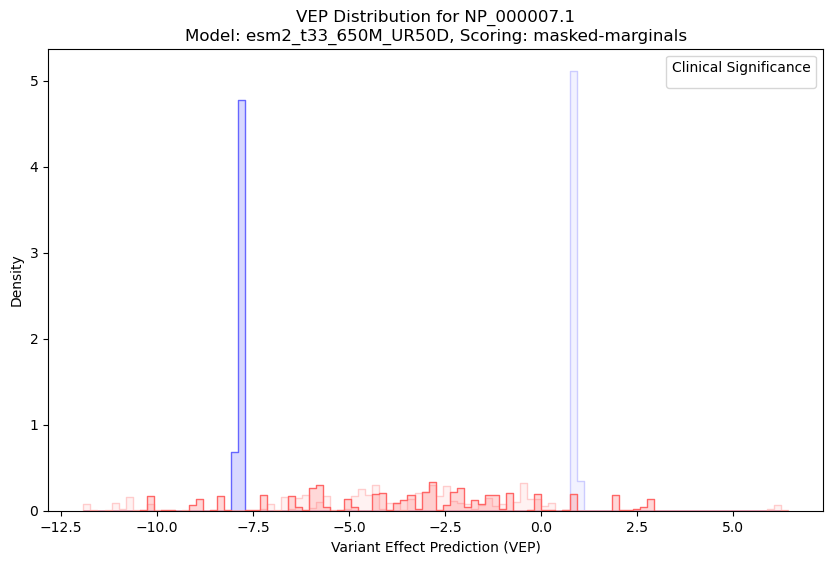

In [10]:
# Group by protein, model_location, and scoring_strategy
# For each group, check if there's overlap between pathogenic and benign VEP distributions
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
overlap_results = []
groupby_cols = ['protein', 'model_location', 'scoring_strategy']

for (protein, model, scoring), group in tqdm(vep_df.groupby(groupby_cols), 
                                             total=len(vep_df.groupby(groupby_cols))):
    # Get benign and pathogenic variants
    benign_variants = group[group['clinsig'].isin(['benign', 'likely_benign'])]
    path_variants = group[group['clinsig'].isin(['path', 'likely_path'])]
    
    # Only proceed if we have both types of variants
    if len(benign_variants) > 0 and len(path_variants) > 0:
        # Get min and max VEP for each category
        benign_min = benign_variants['VEP'].min()
        benign_max = benign_variants['VEP'].max()
        path_min = path_variants['VEP'].min()
        path_max = path_variants['VEP'].max()
        
        # Check for overlap
        has_overlap = (path_min <= benign_max) and (benign_min <= path_max)
        
        # Calculate overlap range if there is overlap
        overlap_range = None
        if has_overlap:
            overlap_min = max(benign_min, path_min)
            overlap_max = min(benign_max, path_max)
            overlap_range = overlap_max - overlap_min
        
        # Store results
        overlap_results.append({
            'protein': protein,
            'model_location': model,
            'scoring_strategy': scoring,
            'benign_count': len(benign_variants),
            'path_count': len(path_variants),
            'benign_min': benign_min,
            'benign_max': benign_max,
            'path_min': path_min,
            'path_max': path_max,
            'has_overlap': has_overlap,
            'overlap_range': overlap_range
        })

# Convert to DataFrame
overlap_df = pd.DataFrame(overlap_results)

# Display summary
print(f"Total protein-model-scoring combinations: {len(overlap_df)}")
print(f"Combinations with VEP overlap between pathogenic and benign variants: {overlap_df['has_overlap'].sum()}")
print(f"Percentage of combinations with overlap: {100 * overlap_df['has_overlap'].mean():.2f}%")

# Display proteins with overlap
if len(overlap_df[overlap_df['has_overlap']]) > 0:
    print("\nProteins with VEP overlap between pathogenic and benign variants:")
    display(overlap_df[overlap_df['has_overlap']].sort_values('overlap_range', ascending=False))

# Visualize one example of overlap if any exists
if overlap_df['has_overlap'].any():
    # Get the protein with the largest overlap
    example_protein = overlap_df.loc[overlap_df['has_overlap'], 'protein'].iloc[0]
    example_model = overlap_df.loc[overlap_df['has_overlap'], 'model_location'].iloc[0]
    example_scoring = overlap_df.loc[overlap_df['has_overlap'], 'scoring_strategy'].iloc[0]
    
    # Filter data for this protein
    example_data = vep_df[(vep_df['protein'] == example_protein) & 
                          (vep_df['model_location'] == example_model) &
                          (vep_df['scoring_strategy'] == example_scoring)]
    
    # Create plot
    plt.figure(figsize=(10, 6))
    sns.histplot(data=example_data, x='VEP', hue='clinsig', 
                 palette=utils.get_clinsig_palette(), 
                 bins=100,
                 element='step', common_norm=False, stat='density')
    plt.title(f"VEP Distribution for {example_protein}\nModel: {example_model}, Scoring: {example_scoring}")
    plt.xlabel("Variant Effect Prediction (VEP)")
    plt.ylabel("Density")
    plt.legend(title="Clinical Significance")
    plt.show()


In [33]:
import src.vep_gmm as vg

gmm_df = vg.train_vep_gmm(vep_df)

Training GMMs: 100%|██████████| 1450/1450 [00:45<00:00, 31.65it/s]


NameError: name 'plot_vep_gmm' is not defined

In [5]:
boundary_crossing_df = vg.get_decision_boundaries(gmm_df, vep_df, plot=False)
boundary_crossing_df.head()

Finding boundary-crossing variants: 100%|██████████| 36074/36074 [00:04<00:00, 8811.81it/s] 


No variants found that cross decision boundaries in different haplotypes


,protein,mutant,clinsig,decision_boundary,min_vep,max_vep,vep_range,haplotype_count,scores_above_boundary,scores_below_boundary,crossing_proportion
0,NP_000007.1,M326T,likely_path,-6.219087,-7.108946,-4.940533,2.168413,16,1,15,0.062500
1,NP_000007.1,P132H,likely_path,-6.219087,-6.589774,-5.512917,1.076857,16,5,11,0.312500
2,NP_000007.1,Q317E,likely_path,-6.219087,-6.965709,-4.721759,2.243949,16,15,1,0.062500
3,NP_000007.1,T193A,likely_path,-6.219087,-6.297962,-6.041366,0.256596,16,15,1,0.062500
4,NP_000009.1,L529F,path,-6.353840,-6.587707,-6.283372,0.304334,45,1,44,0.022222


Find variants where the VEP of a pathogenic variant overlaps with the VEP of a benign variant for some haplotypes but not others

### Embed VEP results in 2D space

In [ ]:
variant_data = vg.get_example_data_for_decision_boundary(boundary_crossing_df, vep_df, top_n=3)[0]
variant_data = hs.add_haplotype_freqs(variant_data)

Getting haplotype frequencies:   0%|          | 0/1 [00:00<?, ?it/s]

Adding haplotype frequencies per population:   0%|          | 0/32 [00:00<?, ?it/s]

Getting haplotype frequencies:   0%|          | 0/1 [00:00<?, ?it/s]

Adding haplotype frequencies per population:   0%|          | 0/32 [00:00<?, ?it/s]

Getting haplotype frequencies:   0%|          | 0/1 [00:00<?, ?it/s]

Adding haplotype frequencies per population:   0%|          | 0/32 [00:00<?, ?it/s]

Getting haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Getting haplotype frequencies:   0%|          | 0/1 [00:00<?, ?it/s]

Using cohorts: {'1000GENOMES:phase_3'}
Using 32 populations

Number of variants specific to each population:
specific_superpopulation
1000GENOMES:phase_3:EAS    11
1000GENOMES:phase_3:EUR    10
1000GENOMES:phase_3:AFR     9
1000GENOMES:phase_3:SAS     8
1000GENOMES:phase_3:AMR     3
Name: count, dtype: int64

Percentage of population-specific haplotypes: 82.00%


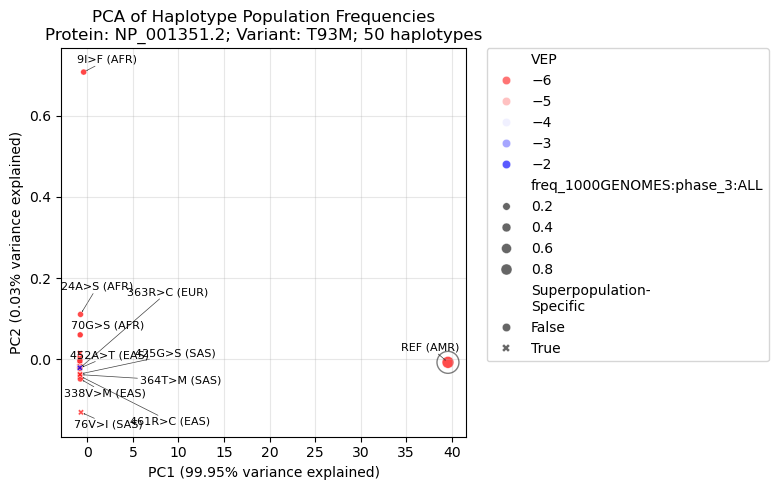

Variance explained by PC1: 99.95%
Variance explained by PC2: 0.03%
Total variance explained: 99.98%


In [26]:
freq_cols = [col for col in variant_data.columns if col.startswith('freq_')]
# superpops = variant_data['top_superpop'].unique().tolist()
# freq_cols = [col for col in freq_cols if col.endswith(tuple(superpops))]


# Run PCA on the population frequency data
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(variant_data.set_index('haplotype').loc[:,freq_cols].fillna(0))

# Apply PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame with the PCA results
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'], 
                      index=variant_data['haplotype'].tolist()
                      ).merge(variant_data, 
                              left_index=True, 
                              right_on='haplotype'
                              ).set_index('haplotype')
# Color by VEP
pca_df['Top\nSuperpopulation'] = pca_df['top_superpop'].str.split(':').str[-1]
pca_df['Superpopulation-\nSpecific'] = pca_df['nonzero_superpop_freqs']==1

pca_df.sort_values(['Top\nSuperpopulation','VEP'],inplace=True)
# Apply MinMax scaling to normalize VEP scores between 0 and 1
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
pca_df['VEP\n(normalized)'] = 1- scaler.fit_transform(pca_df[['VEP']]).flatten()
# Plot the PCA results using seaborn
plt.figure(figsize=(8, 5))  # Increased width to accommodate legend outside
sns.scatterplot(data=pca_df, 
                x='PC1',
                y='PC2', 
                size="freq_1000GENOMES:phase_3:ALL",
                # size="VEP\n(normalized)",
                # sizes=(50, 200),
                # hue='Top\nSuperpopulation',
                # palette=utils.get_superpop_palette(),
                hue='VEP',
                palette="bwr_r",

                style='Superpopulation-\nSpecific',
                alpha=0.75, 
                
                )
plt.title(f'PCA of Haplotype Population Frequencies\nProtein: {pca_df.iloc[0]["protein"]}; Variant: {pca_df.iloc[0]["mutant"]}; {pca_df.shape[0]} haplotypes')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance explained)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance explained)')

# Move legend outside the plot to the right
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

# Add annotations with repel labels
from adjustText import adjust_text
# Create a list to store annotation objects
texts = []
label_topn = 10
pca_df.sort_values(["top_superpop_freq",'VEP'], ascending=False, inplace=True)
for i, (haplotype, row) in enumerate(pca_df.iterrows()):  # Annotate first 10 points
    if i > label_topn:
        break
    txt = haplotype.split(':')[-1]
    if 'top_superpop' in row.index:
        txt = f"{txt} ({row['top_superpop'].split(':')[-1]})"
    # Create annotation and add to list
    texts.append(plt.text(x=pca_df['PC1'].iloc[i], 
                          y=pca_df['PC2'].iloc[i], 
                          s=txt,
                          fontsize=8))

# Apply the repel algorithm to prevent overlapping labels
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='black', lw=0.5, alpha=.75), expand=(1.2, 3))

# Add a black ring around the reference haplotype
ref_data = pca_df.loc[pca_df.is_ref==True]
if len(ref_data) > 0:
    plt.scatter(
        ref_data['PC1'], 
        ref_data['PC2'], 
        s=250,  # Slightly larger than the largest point
        facecolors='none', 
        edgecolors='black', 
        linewidths=1,
        alpha=.5,
        zorder=10  # Ensure it's drawn on top of other points
    )

plt.grid(alpha=0.3)
plt.tight_layout()  # Adjust layout to make room for the legend
plt.show()

# Print variance explained
print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_[:2]):.2%}")


In [11]:
# Get proteins where VEP is 0
print(vep_df.loc[vep_df['VEP']==0]['protein'].nunique())

# Get proteins where VEP is NA
print(vep_df.loc[vep_df['VEP'].isna()]['protein'].nunique())

154
426


In [27]:
vep_df.groupby(['scoring_strategy'])['VEP'].describe()

,count,mean,std,min,25%,50%,75%,max
scoring_strategy,,,,,,,,
masked-marginals,2018520.0,-4.144918,4.357218,-17.24873,-7.657737,-2.872711,-0.539179,8.845604


In [7]:
print(vep_df.shape)
print(vep_df.model_location.nunique(),"model(s)")
print(vep_df.protein.nunique(),"protein(s)")
print(vep_df.haplotype.nunique(),"haplotypes(s)")
print((vep_df.protein + '_' + vep_df.mutant).nunique(),"mutantation(s)")
print(vep_df.scoring_strategy.nunique(),"scoring strategy(ies)")

vep_df.head()

(2028077, 72)
1 model(s)
1450 protein(s)
57984 haplotypes(s)
36074 mutantation(s)
1 scoring strategy(ies)


,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig
0,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,L1045F,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-3.635069,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947347,67473,G,A,.,PASS,67473,7:150947347,A,3757,NM_000238.4,Transcript,missense_variant,3541,3133,1045,L/F,Ctc/Ttc,-,MODERATE,-,-1,-,-,-,G,G,-,NM_000238.4:c.3133C>T,NP_000229.1:p.Leu1045Phe,-,NaN,0.00000,78369,"MedGen:CN230736|EFO:EFO_0004269,Human_Phenotyp...",Cardiovascular_phenotype|Cardiac_arrhythmia|Co...,NC_000007.14:g.150947347G>A,"criteria_provided,_multiple_submitters,_no_con...",Benign,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,SO:0001583|missense_variant,1,199473025.0,NaN,ClinGen:CA008015,NaN,NaN,NaN,NaN,NaN,-6.731237,-0.021689,6,benign
1,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,D1003Y,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-1.670645,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947473,200516,C,A,.,PASS,200516,7:150947473,A,3757,NM_000238.4,Transcript,missense_variant,3415,3007,1003,D/Y,Gac/Tac,-,MODERATE,-,-1,-,-,-,C,C,-,NM_000238.4:c.3007G>T,NP_000229.1:p.Asp1003Tyr,-,NaN,NaN,197155,MedGen:CN517202,not_provided,NC_000007.14:g.150947473C>A,"criteria_provided,_single_submitter",Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,794728402.0,NaN,ClinGen:CA007791,NaN,NaN,NaN,NaN,NaN,-2.509515,-0.039753,6,likely_path
2,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,N996I,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-4.619007,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947493,67458,T,A,.,PASS,67458,7:150947493,A,3757,NM_000238.4,Transcript,missense_variant,3395,2987,996,N/I,aAc/aTc,-,MODERATE,-,-1,-,-,-,T,T,-,NM_000238.4:c.2987A>T,NP_000229.1:p.Asn996Ile,-,NaN,NaN,78354,"MONDO:MONDO:0019171,MedGen:C1141890,OMIM:PS192...",Congenital_long_QT_syndrome|not_provided|Long_...,NC_000007.14:g.150947493T>A,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,199473018.0,NaN,ClinGen:CA007728|UniProtKB:Q12809#VAR_068285,NaN,NaN,NaN,NaN,NaN,-5.869637,-0.057342,6,likely_path
3,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,E978K,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-0.514701,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947639,67453,C,T,.,PASS,67453,7:150947639,T,3757,NM_000238.4,Transcript,missense_variant,3340,2932,978,E/K,Gag/Aag,-,MODERATE,-,-1,-,-,-,C,C,-,NM_000238.4:c.2932G>A,NP_000229.1:p.Glu978Lys,-,0.00008,0.00039,78349,"EFO:EFO_0004269,Human_Phenotype_Ontology:HP:00...",Cardiac_arrhythmia|Cardiovascular_phenotype|no...,NC_000007.14:g.150947639C>T,"criteria_provided,_multiple_submitters,_no_con...",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,K

### Check whether the VEP is affected by whether the variant is already in the haplotype

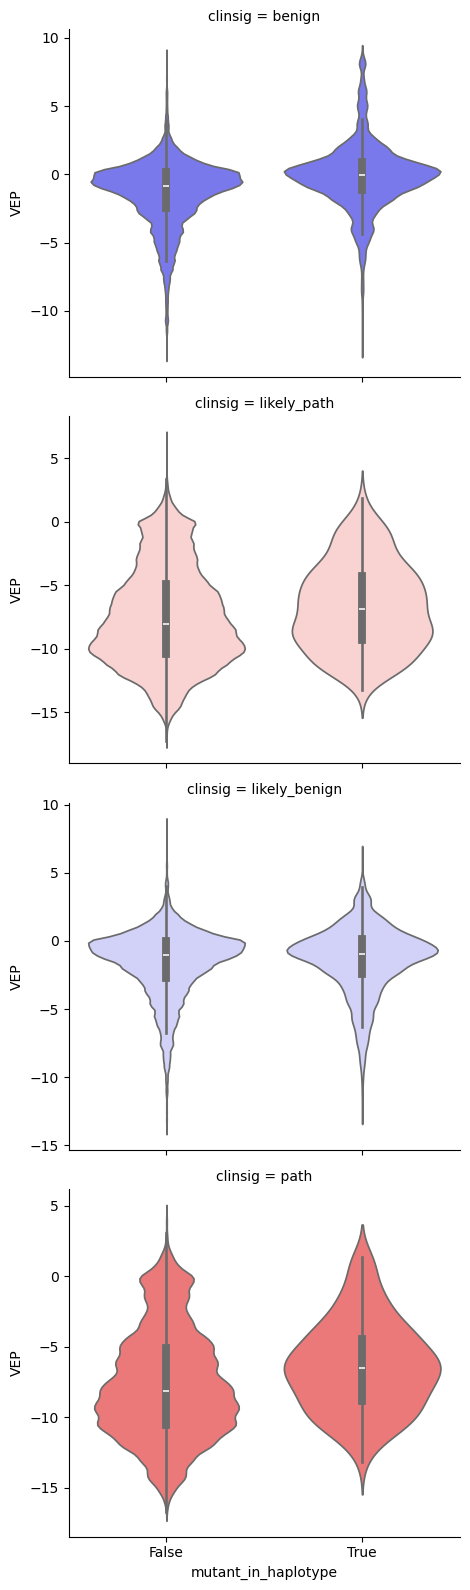

In [6]:
import seaborn as sns
g = sns.FacetGrid(data=vep_df, 
                   row='clinsig',    
                   sharey=False,
                   height=4, aspect=1.2)
g.map_dataframe(sns.violinplot, 
                x='mutant_in_haplotype', 
                y='VEP',
                hue='clinsig',
                palette=utils.get_clinsig_palette())
g.tight_layout()

### Check out of frame mutants

These should all be filtered out automatically by the vep_pipeline, but just to check.

In [16]:
# Import haplotypes if not already defined
if 'haplotypes' not in locals():
    haplotypes = hs.get_haplotypes(
        tx_ids=vep_df['ENST'].unique().tolist(),
        cache_only=True
    )

# Add haplotype sequences to the VEP dataframe
vep_df = va.add_mutant_out_of_frame(vep_df, 
                                    haplotypes=haplotypes,
                                    force=True)


# Check if any haplotypes with variants that are out of frame
print(vep_df.loc[vep_df['mutant_out_of_frame']==True]['haplotype'].unique().tolist()[:10])


# Filter out variants that are out of frame, as they should not not be able to produce a VEP
# vep_df = vep_df.loc[vep_df['mutant_out_of_frame']==False]
vep_df.head()

Found haplotypes of 47325 transcripts in: '/home/schilder/.cache/ensembl_rest/haplotypes'


Getting haplotypes:   0%|          | 0/1450 [00:00<?, ?it/s]

Adding 'haplotype_sequence' column
Getting haplotype sequences


Adding reference haplotype:   0%|          | 0/1450 [00:00<?, ?it/s]

Getting haplotype sequences:   0%|          | 0/1450 [00:00<?, ?it/s]

Getting haplotype names:   0%|          | 0/1450 [00:00<?, ?it/s]

Adding 'haplotype_sequence' column
Adding 'haplotype_sequence_len' column
Adding 'mutant_out_of_frame' column
['ENSP00000333994:128Q>*,129del{20}', 'ENSP00000333994:16W>*,17del{132}', 'ENSP00000333994:18K>*,19del{130}', 'ENSP00000333994:40Q>*,41del{108}', 'ENSP00000003084:470V>M,553R>*,554del{928}', 'ENSP00000350283:12Q>*,13del{1852}', 'ENSP00000351832:232R>*,233del{1162}', 'ENSP00000347719:10G>C,231W>*,232del{962}', 'ENSP00000290650:363Y>*,364del{1387}', 'ENSP00000246868:62K>*,63del{189}']


,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,haplotype_sequence,reference_sequence_len,haplotype_sequence_len,mutant_out_of_frame
0,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,L1045F,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-3.635069,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947347,67473,G,A,.,PASS,67473,7:150947347,A,3757,NM_000238.4,Transcript,missense_variant,3541,3133,1045,L/F,Ctc/Ttc,-,MODERATE,-,-1,-,-,-,G,G,-,NM_000238.4:c.3133C>T,NP_000229.1:p.Leu1045Phe,-,NaN,0.00000,78369,"MedGen:CN230736|EFO:EFO_0004269,Human_Phenotyp...",Cardiovascular_phenotype|Cardiac_arrhythmia|Co...,NC_000007.14:g.150947347G>A,"criteria_provided,_multiple_submitters,_no_con...",Benign,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,SO:0001583|missense_variant,1,199473025.0,NaN,ClinGen:CA008015,NaN,NaN,NaN,NaN,NaN,-6.731237,-0.021689,6,benign,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,1159,1159.0,False
1,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,D1003Y,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-1.670645,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947473,200516,C,A,.,PASS,200516,7:150947473,A,3757,NM_000238.4,Transcript,missense_variant,3415,3007,1003,D/Y,Gac/Tac,-,MODERATE,-,-1,-,-,-,C,C,-,NM_000238.4:c.3007G>T,NP_000229.1:p.Asp1003Tyr,-,NaN,NaN,197155,MedGen:CN517202,not_provided,NC_000007.14:g.150947473C>A,"criteria_provided,_single_submitter",Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,794728402.0,NaN,ClinGen:CA007791,NaN,NaN,NaN,NaN,NaN,-2.509515,-0.039753,6,likely_path,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,1159,1159.0,False
2,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,N996I,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-4.619007,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947493,67458,T,A,.,PASS,67458,7:150947493,A,3757,NM_000238.4,Transcript,missense_variant,3395,2987,996,N/I,aAc/aTc,-,MODERATE,-,-1,-,-,-,T,T,-,NM_000238.4:c.2987A>T,NP_000229.1:p.Asn996Ile,-,NaN,NaN,78354,"MONDO:MONDO:0019171,MedGen:C1141890,OMIM:PS192...",Congenital_long_QT_syndrome|not_provided|Long_...,NC_000007.14:g.150947493T>A,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,199473018.0,NaN,ClinGen:CA007728|UniProtKB:Q12809#VAR_068285,NaN,NaN,NaN,NaN,NaN,-5.869637,-0.057342,6,likely_path,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,1159,1159.0,False
3,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,E978K,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-0.514701,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947639,67453,C,T,.,PASS,67453,7:150947639,T,3757,NM_000238.4,Transcript,missense_variant,3340,2932,978,E/K,Gag/Aag,-,MODERATE,-,-1,-,-,-,C,C,-,NM_000238.4:c.2932G

### Count haplotypes where the variant is already in the WT sequence

In [18]:
vep_df.loc[vep_df['mutant_in_haplotype']==True].groupby(['clinsig'])['haplotype'].nunique()

clinsig
benign           19714
likely_benign     9030
likely_path        320
path               164
Name: haplotype, dtype: int64

Axes(0.125,0.11;0.775x0.77)
count    2.026074e+06
mean     9.956892e-01
std      5.219368e-02
min      5.904455e-03
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.012841e+00
Name: haplotype_sequence_len_pct, dtype: float64


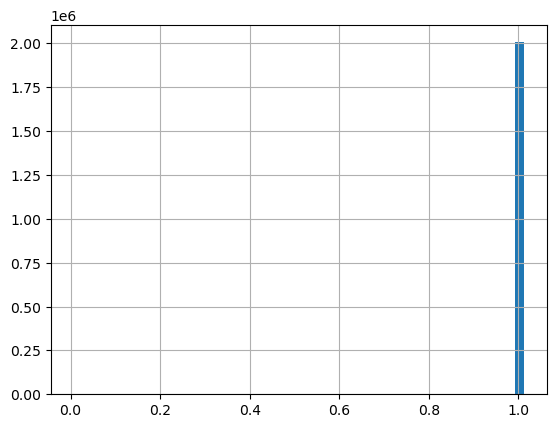

In [19]:
print(vep_df['haplotype_sequence_len_pct'].hist(bins=50))
print(vep_df['haplotype_sequence_len_pct'].describe())


(2204, 6)


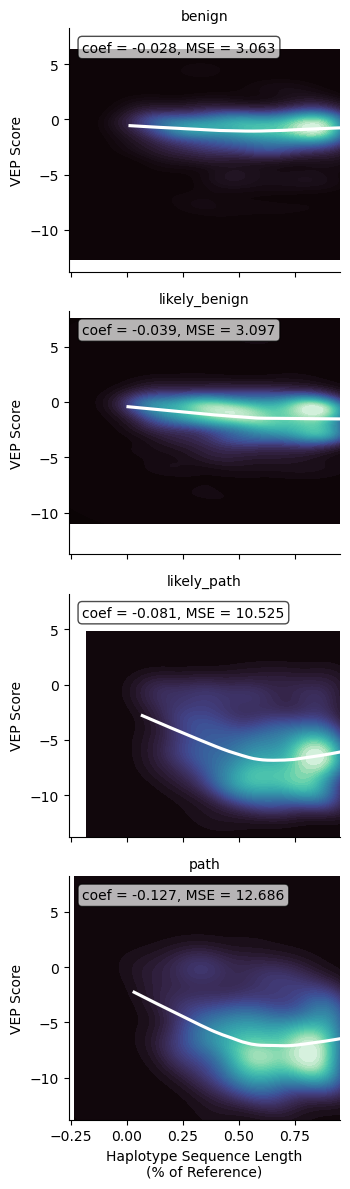

In [21]:
# Plot haplotype_sequence_len_pct vs VEP as point density with regression line
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats


# Get the per-protein mean to reduce the size of the dataset
# Downsample to 1000 random rows per protein
# plot_data = vep_df.loc[vep_df['mutant_out_of_frame']==False].sample(100000, random_state=42)
plot_data = vep_df.groupby(['model_location','protein','haplotype','haplotype_sequence_len_pct','clinsig'], observed=True).agg({'VEP': 'mean'}).reset_index()
max_pct = .95
plot_data = plot_data.loc[plot_data['haplotype_sequence_len_pct'] < max_pct]
print(plot_data.shape)
plot_data.head()

# Create a categorical column with the defined order
plot_data['clinsig'] = pd.Categorical(
    plot_data['clinsig'], 
    categories=list(utils.get_clinsig_palette().keys())[::-1], 
    ordered=True
)
# Sort the dataframe by the ordered categorical column
plot_data = plot_data.sort_values('clinsig')

min_vep = plot_data['VEP'].min()
 

# Create new plot
g = sns.FacetGrid(plot_data, 
                row='clinsig',  
                sharex=True,
                sharey=True, 
                aspect=1.2)
# Map the custom function to the FacetGrid
g.map_dataframe(sns.kdeplot,
                 x="haplotype_sequence_len_pct",
                 y="VEP", 
                 fill=True, 
                 thresh=0, levels=50, cmap="mako",
                 bw_adjust=1, 
                 clip=[(None,max_pct),(min_vep, None)],
                 extend="both",
                 alpha=1.0
                 )
g.map_dataframe(sns.regplot,
                x="haplotype_sequence_len_pct",
                y="VEP", 
                scatter=False,
                lowess=True,
                line_kws={"color": "white"}
                )

# Calculate and add Pearson correlation for each subplot
for i, clinsig in enumerate(plot_data['clinsig'].cat.categories):
    subset = plot_data[plot_data['clinsig'] == clinsig].dropna(subset=['haplotype_sequence_len_pct', 'VEP'])
    # r, p = stats.spearmanr(subset['haplotype_sequence_len_pct'], subset['VEP'])
    # r2 = r**2 

    import numpy as np
    import statsmodels.api as sm
    from sklearn.metrics import mean_squared_error


    # Sample data (replace with your actual data)
    x_actual = subset['haplotype_sequence_len_pct']
    y_actual = subset['VEP']

    # Fit LOESS model
    lowess = sm.nonparametric.lowess(y_actual, x_actual, frac=0.3)
    x_predicted = lowess[:, 0]
    y_predicted = lowess[:, 1]

    # Calculate SS_res
    residuals = y_actual - y_predicted
    ss_res = np.sum(residuals**2)

    # Calculate SS_tot
    y_mean = np.mean(y_actual)
    ss_tot = np.sum((y_actual - y_mean)**2)

    # Calculate pseudo R-squared
    r2 = 1 - (ss_res / ss_tot)

    # Calculate MSE
    mse = mean_squared_error(y_actual, y_predicted)
    
    ax = g.axes[i, 0]
    ax.text(0.05, 0.95, f'coef = {r2:.3f}, MSE = {mse:.3f}', 
            transform=ax.transAxes, 
            fontsize=10, 
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    
                 
# Set labels and titles
g.set_xlabels('Haplotype Sequence Length\n(% of Reference)')
g.set_ylabels('VEP Score')
g.set_titles('{row_name}')
g.tight_layout()
plt.show()


### Count number of pathogenic variants already in the haplotype

In [8]:
vep_df = hs.add_haplotype_diffs(vep_df,
                                haplotypes=haplotypes, 
                                force=True)
vep_df.head()

Extracting haplotype diffs:   0%|          | 0/1450 [00:00<?, ?it/s]

95481 diffs from 1450 haplotypes extracted


,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,haplotype_sequence,reference_sequence_len,haplotype_sequence_len,mutant_out_of_frame,diff_benign,diff_possibly damaging,diff_probably damaging,diff_unknown
0,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,L1045F,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-3.635069,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947347,67473,G,A,.,PASS,67473,7:150947347,A,3757,NM_000238.4,Transcript,missense_variant,3541,3133,1045,L/F,Ctc/Ttc,-,MODERATE,-,-1,-,-,-,G,G,-,NM_000238.4:c.3133C>T,NP_000229.1:p.Leu1045Phe,-,NaN,0.00000,78369,"MedGen:CN230736|EFO:EFO_0004269,Human_Phenotyp...",Cardiovascular_phenotype|Cardiac_arrhythmia|Co...,NC_000007.14:g.150947347G>A,"criteria_provided,_multiple_submitters,_no_con...",Benign,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,SO:0001583|missense_variant,1,199473025.0,NaN,ClinGen:CA008015,NaN,NaN,NaN,NaN,NaN,-6.731237,-0.021689,6,benign,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,1159,1159.0,False,0.0,0.0,0.0,0.0
1,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,D1003Y,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-1.670645,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947473,200516,C,A,.,PASS,200516,7:150947473,A,3757,NM_000238.4,Transcript,missense_variant,3415,3007,1003,D/Y,Gac/Tac,-,MODERATE,-,-1,-,-,-,C,C,-,NM_000238.4:c.3007G>T,NP_000229.1:p.Asp1003Tyr,-,NaN,NaN,197155,MedGen:CN517202,not_provided,NC_000007.14:g.150947473C>A,"criteria_provided,_single_submitter",Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,794728402.0,NaN,ClinGen:CA007791,NaN,NaN,NaN,NaN,NaN,-2.509515,-0.039753,6,likely_path,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,1159,1159.0,False,0.0,0.0,0.0,0.0
2,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,N996I,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-4.619007,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947493,67458,T,A,.,PASS,67458,7:150947493,A,3757,NM_000238.4,Transcript,missense_variant,3395,2987,996,N/I,aAc/aTc,-,MODERATE,-,-1,-,-,-,T,T,-,NM_000238.4:c.2987A>T,NP_000229.1:p.Asn996Ile,-,NaN,NaN,78354,"MONDO:MONDO:0019171,MedGen:C1141890,OMIM:PS192...",Congenital_long_QT_syndrome|not_provided|Long_...,NC_000007.14:g.150947493T>A,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,199473018.0,NaN,ClinGen:CA007728|UniProtKB:Q12809#VAR_068285,NaN,NaN,NaN,NaN,NaN,-5.869637,-0.057342,6,likely_path,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,1159,1159.0,False,0.0,0.0,0.0,0.0
3,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,E978K,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-0.514701,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947639,67453,C,T,.,PASS,67453,7:150947639,T

plot data shape:  (212314, 7)


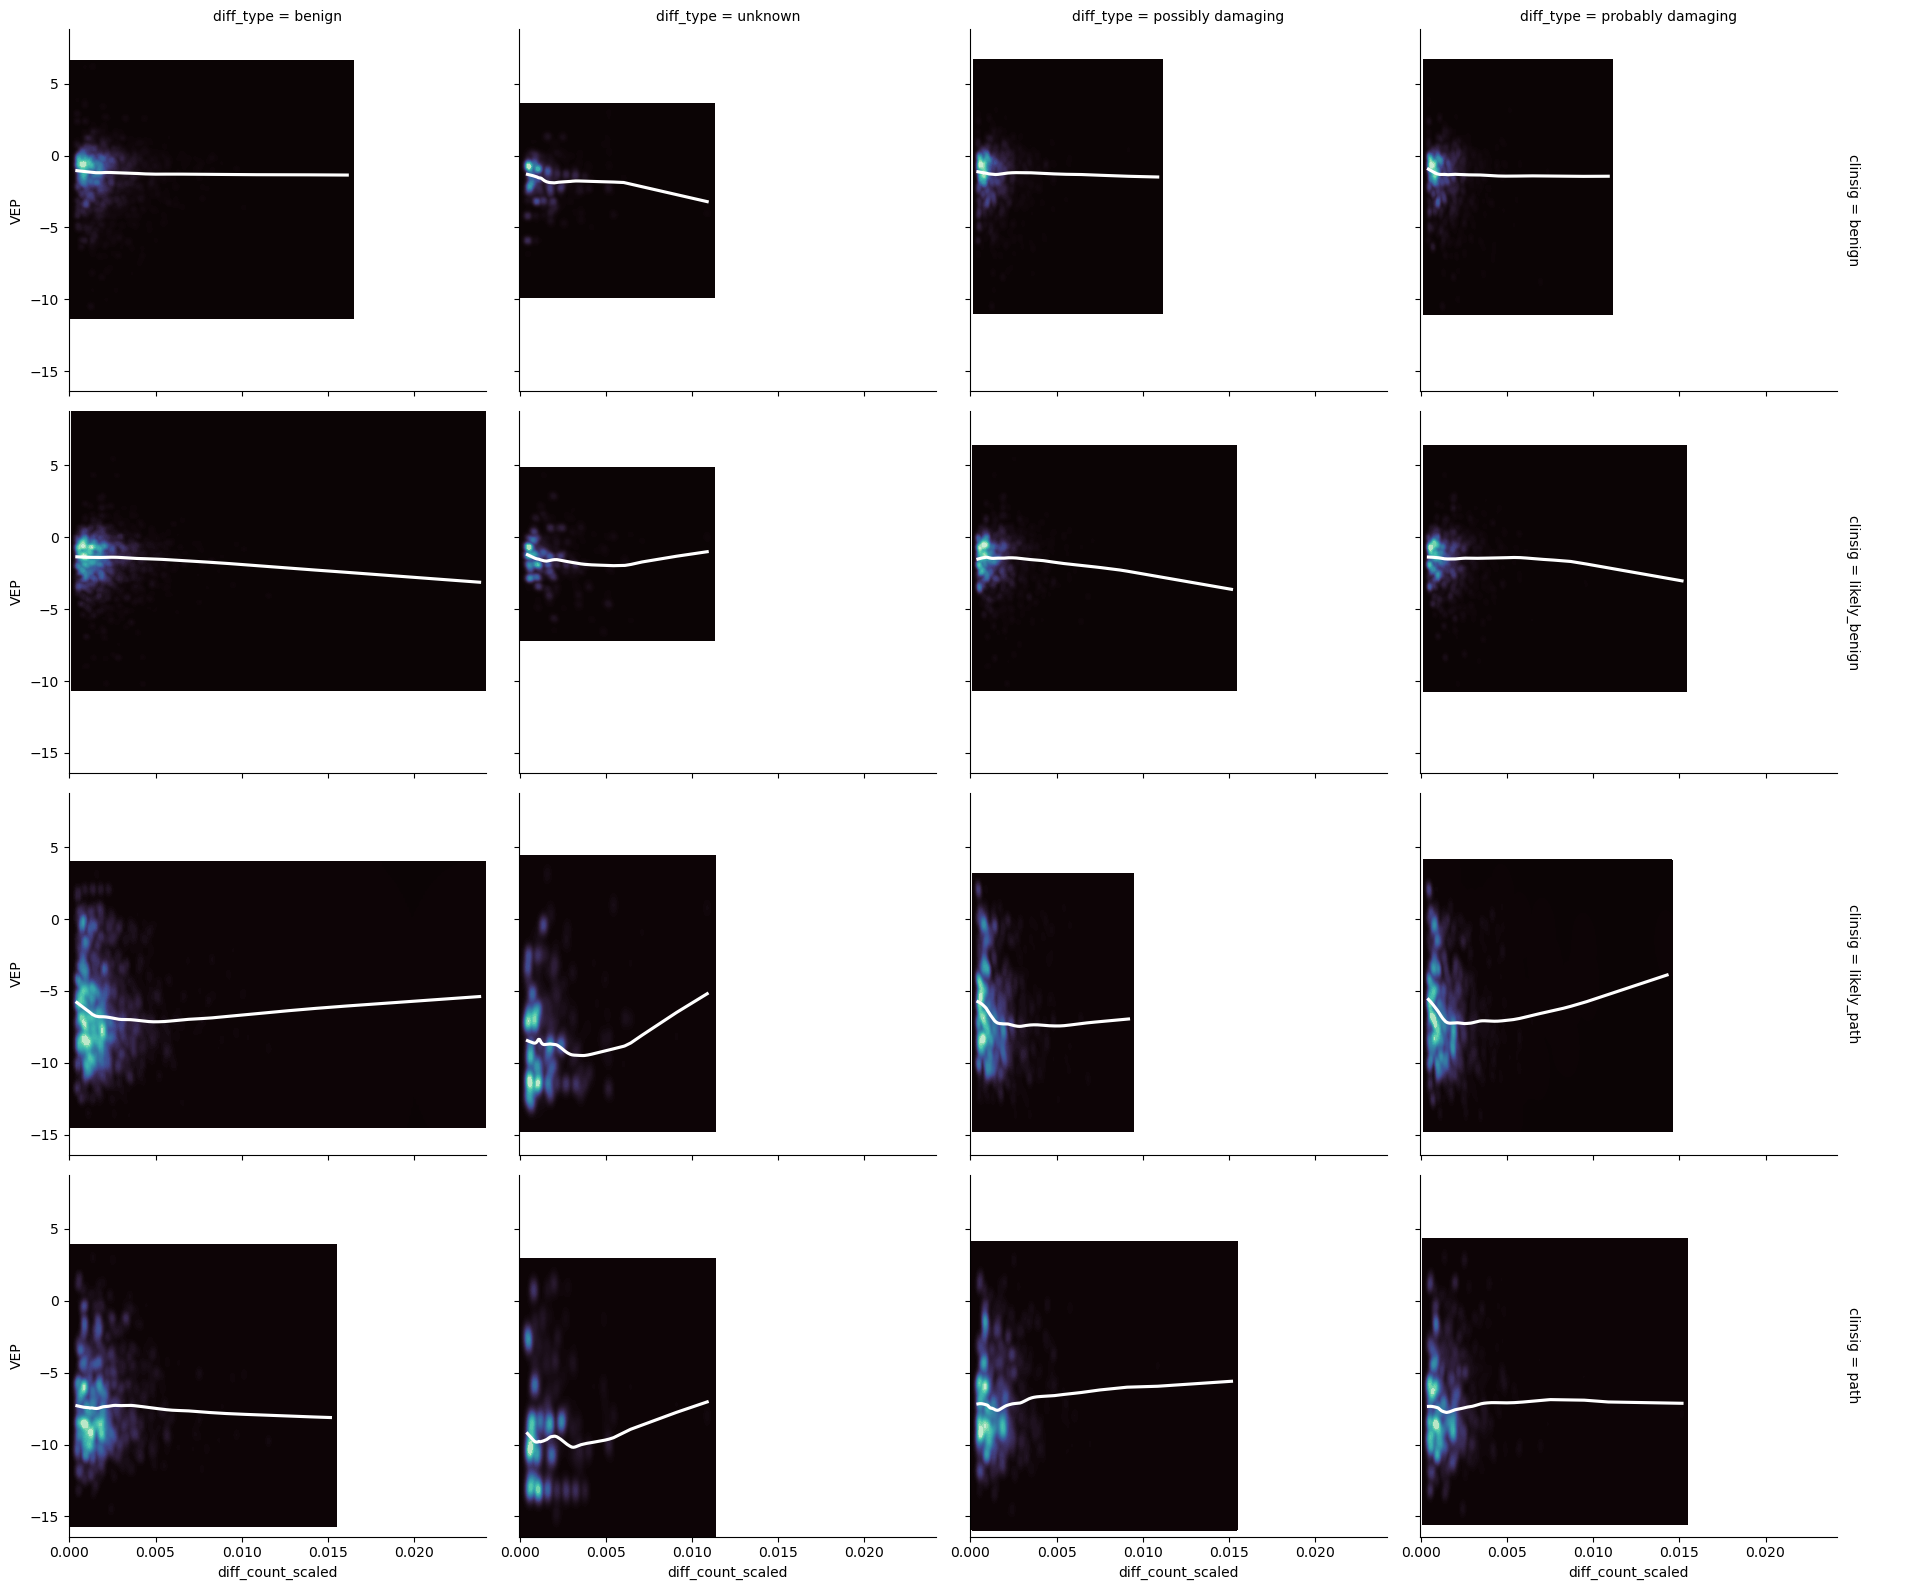

In [62]:
# Melt the diff columns to create a long-format dataframe
diff_cols = [col for col in vep_df.columns if col.startswith('diff_')]
plot_data = vep_df.loc[(vep_df['VEP'].notna()) & (vep_df['mutant_in_haplotype']==False)].melt(
    id_vars=['model_location', 'protein', 'haplotype', 'clinsig', 'VEP','haplotype_sequence_len'],
    value_vars=diff_cols,
    var_name='diff_type',
    value_name='diff_count'
)
plot_data['diff_count_scaled'] = plot_data['diff_count'] / plot_data['haplotype_sequence_len']

plot_data = plot_data.loc[plot_data['diff_count'] > 0]

# Create a categorical column with the defined order
plot_data['clinsig'] = pd.Categorical(
    plot_data['clinsig'], 
    categories=list(utils.get_clinsig_palette().keys())[::-1], 
    ordered=True
)
# Clean up the diff_type column by removing the 'diff_' prefix
plot_data['diff_type'] = plot_data['diff_type'].str.replace('diff_', '')
plot_data['diff_type'] = pd.Categorical(
    plot_data['diff_type'], 
    categories=['benign','unknown', 'possibly damaging', 'probably damaging'], 
    ordered=True
)
# Sort the dataframe by the ordered categorical column
plot_data = plot_data.sort_values(['clinsig','diff_type'])

# # Group by relevant columns and calculate mean VEP score
plot_data = plot_data.groupby(['model_location', 'protein', 'haplotype','clinsig', 'diff_type','diff_count_scaled'], observed=True).agg({'VEP': 'mean'}).reset_index()

# plot_data = plot_data.loc[plot_data['diff_type'] == 'probably damaging']

# plot_data = plot_data.groupby(['clinsig', 'diff_type'], observed=True).sample(1000, random_state=42).reset_index(drop=True)

print("plot data shape: ", plot_data.shape)

g = sns.FacetGrid(data=plot_data, 
                  col='diff_type',
                   row='clinsig',
                   margin_titles=True,
                   height=4, aspect=1.2)
g.map_dataframe(sns.kdeplot, 
                x='diff_count_scaled', 
                y='VEP',
                fill=True,
                thresh=0, levels=50, cmap="mako",
                bw_adjust=0.5, 
                # clip=[(None,max_pct),(min_vep, None)],
                extend="both",
                alpha=1.0
                )
g.map_dataframe(sns.regplot,
                x="diff_count_scaled",
                y="VEP", 
                scatter=False,
                lowess=True,
                line_kws={"color": "white"}
                )
g.add_legend()

In [ ]:
# # Remove any existing hap_mutations columns if they exist
# force = True
# if any([col for col in vep_df.columns if col.startswith('n_')]) and force:
#     vep_df = vep_df.drop(columns=[col for col in vep_df.columns if col.startswith('n_')])

# # Pivot the table to create columns for each clinsig category
# hap_mutations = vep_df.loc[vep_df['mutant_in_haplotype']==True].pivot_table(
#     index='haplotype',
#     columns='clinsig',
#     values='mutant',
#     aggfunc='nunique',
#     fill_value=0
# ).add_prefix('nWT_')

# # Convert all columns to integer type
# hap_mutations = hap_mutations.astype(int)
# hap_mutations
# #merge back into vep_df
# vep_df = vep_df.merge(hap_mutations, left_on='haplotype', right_index=True, how='left')
# vep_df[hap_mutations.columns] = vep_df[hap_mutations.columns].fillna(0)
# vep_df.head()
# # Plot haplotype_sequence_len_pct vs VEP as point density with regression line

,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,reference_sequence_len,haplotype_sequence,haplotype_sequence_len,mutant_out_of_frame,haplotype_sequence_len_pct,nWT_benign,nWT_likely_benign,nWT_likely_path,nWT_path
0,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,L1045F,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-3.635069,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947347,67473,G,A,.,PASS,67473,7:150947347,A,3757,NM_000238.4,Transcript,missense_variant,3541,3133,1045,L/F,Ctc/Ttc,-,MODERATE,-,-1,-,-,-,G,G,-,NM_000238.4:c.3133C>T,NP_000229.1:p.Leu1045Phe,-,NaN,0.00000,78369,"MedGen:CN230736|EFO:EFO_0004269,Human_Phenotyp...",Cardiovascular_phenotype|Cardiac_arrhythmia|Co...,NC_000007.14:g.150947347G>A,"criteria_provided,_multiple_submitters,_no_con...",Benign,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,SO:0001583|missense_variant,1,199473025.0,NaN,ClinGen:CA008015,NaN,NaN,NaN,NaN,NaN,-6.731237,-0.021689,6,benign,1159,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,1159.0,False,1.0,0.0,0.0,0.0,0.0
1,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,D1003Y,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-1.670645,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947473,200516,C,A,.,PASS,200516,7:150947473,A,3757,NM_000238.4,Transcript,missense_variant,3415,3007,1003,D/Y,Gac/Tac,-,MODERATE,-,-1,-,-,-,C,C,-,NM_000238.4:c.3007G>T,NP_000229.1:p.Asp1003Tyr,-,NaN,NaN,197155,MedGen:CN517202,not_provided,NC_000007.14:g.150947473C>A,"criteria_provided,_single_submitter",Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,794728402.0,NaN,ClinGen:CA007791,NaN,NaN,NaN,NaN,NaN,-2.509515,-0.039753,6,likely_path,1159,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,1159.0,False,1.0,0.0,0.0,0.0,0.0
2,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,N996I,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-4.619007,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947493,67458,T,A,.,PASS,67458,7:150947493,A,3757,NM_000238.4,Transcript,missense_variant,3395,2987,996,N/I,aAc/aTc,-,MODERATE,-,-1,-,-,-,T,T,-,NM_000238.4:c.2987A>T,NP_000229.1:p.Asn996Ile,-,NaN,NaN,78354,"MONDO:MONDO:0019171,MedGen:C1141890,OMIM:PS192...",Congenital_long_QT_syndrome|not_provided|Long_...,NC_000007.14:g.150947493T>A,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,199473018.0,NaN,ClinGen:CA007728|UniProtKB:Q12809#VAR_068285,NaN,NaN,NaN,NaN,NaN,-5.869637,-0.057342,6,likely_path,1159,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,1159.0,False,1.0,0.0,0.0,0.0,0.0
3,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,E978K,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-0.514701,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947639,67453,C,T,.,PA

In [10]:
# haplotypes = hs.get_haplotypes(
#     cache_only=True 
#     ) 
# vep_df['protein_id'] = vep_df['haplotype'].str.split(':').str[0]

# vep_df = hs.add_haplotype_freqs(df= vep_df, 
#                                 haplotypes = haplotypes, 
#                                 haplotype_col = "haplotype")
# vep_df.head() 

In [11]:
# seq_check_df, clinsig_counts, mutant_in_haplotype = va.report_vep(vep_df)
# display(seq_check_df, clinsig_counts, mutant_in_haplotype)

## Plots: All Proteins

### Density plots

Filtered 0.5% of rows with NAs in col 'VEP'


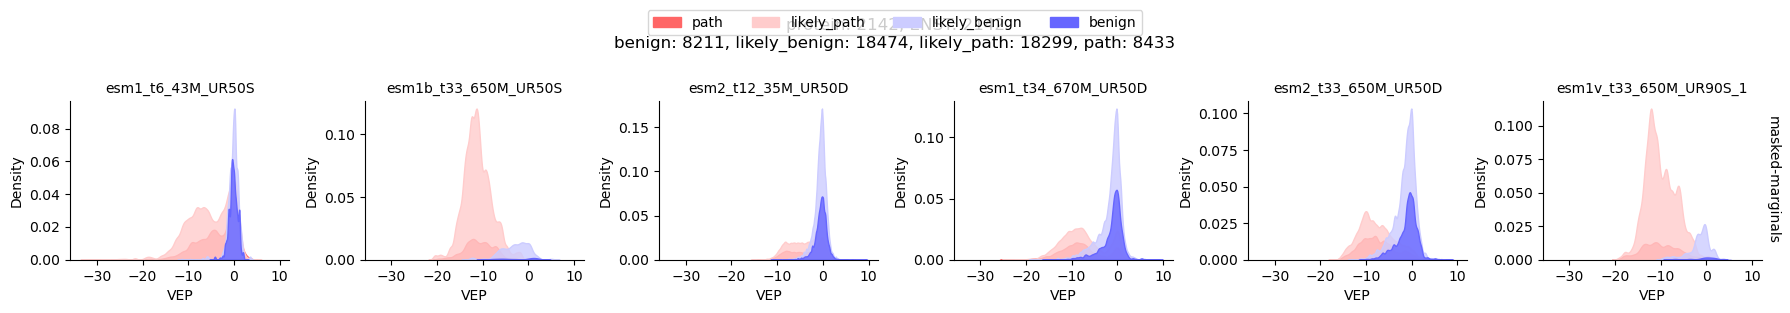

In [9]:
va.plot_vep_density(vep_df, 
                     multiple=['layer','stack','fill'][0],
                     row='scoring_strategy',
                     col='model_location',    
                     legend_y=1.1,
                     aspect=1,
                     save_path="results/plots/vep_density.png"
                     )

### Variance plots

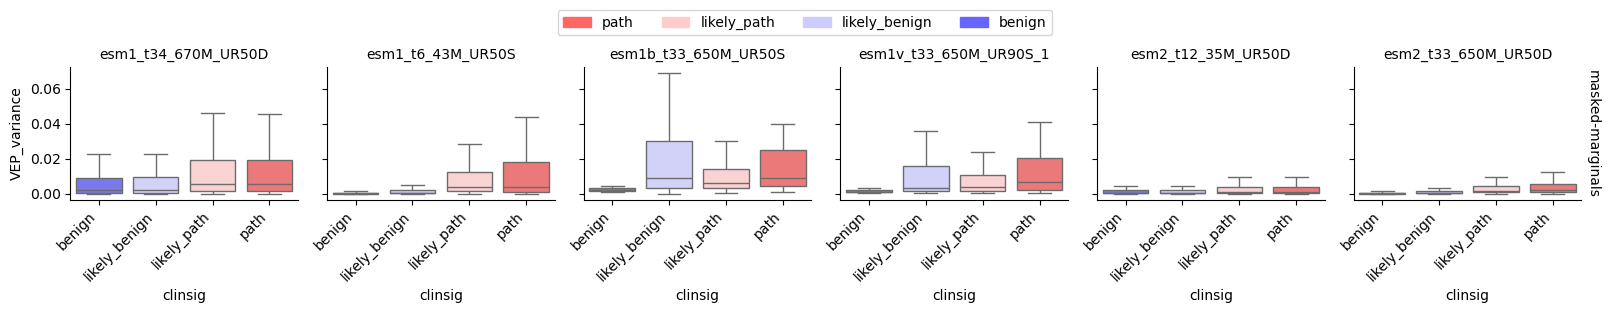

In [13]:
vep_variance = va.plot_vep_variance(vep_df, 
                                    return_df=True,
                                    showfliers=False,
                                    col='model_location',
                                    row='scoring_strategy',
                                    # save_path="results/plots/vep_variance.png",
                                    groupby_cols = ['model_location','protein',
                                                    'clinsig','mutant','scoring_strategy'],
                                    height=3
                                    )

### VEP modality plots

Within each protein, capture the modality of their distributions.

In [25]:
sample = [6.23, 5.58, 7.06, 6.42, 5.20]  # one-mile run times (minutes)
from scipy import stats
res = stats.ecdf(sample)
res.cdf.quantiles
res.cdf.evaluate(sample)

array([0.6, 0.4, 1. , 0.8, 0.2])

,x,y,n_peaks,n_samples
0,-2.598999,0.083333,4,12
1,-2.582740,0.250000,4,12
2,-2.566481,0.250000,4,12
3,-2.550223,0.250000,4,12
4,-2.533964,0.250000,4,12


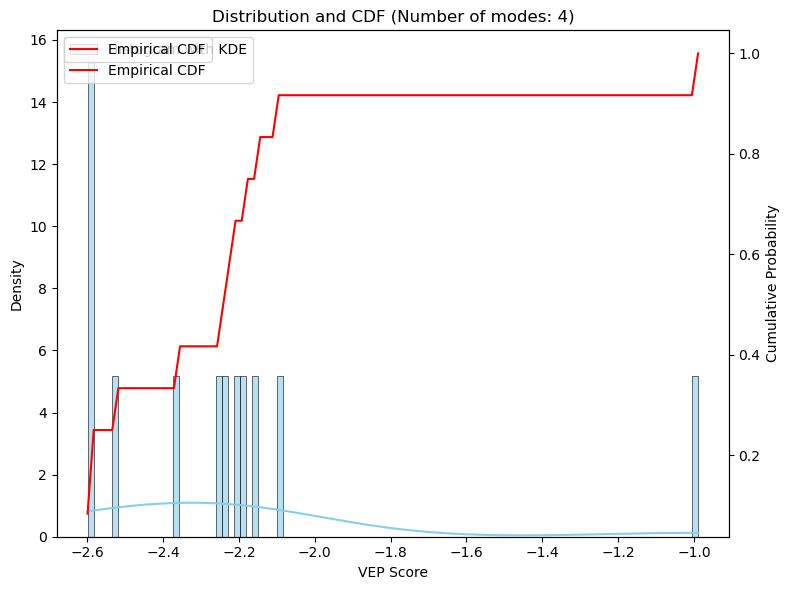

In [28]:
i = 2
dat = vep_df.dropna(subset=['VEP']).loc[(vep_df['model_location']==vep_df['model_location'].unique()[0]) &\
                                        (vep_df['protein']==vep_df['protein'].unique()[i]) &\
                                        (vep_df['scoring_strategy']=='masked-marginals')]
dat = dat.loc[dat['mutant'] == dat['mutant'].unique()[10]]
# utils.get_kde(dat['VEP'],
#                   title=f"Protein: {dat['protein'].tolist()[0]}, Scoring strategy: {dat['scoring_strategy'].tolist()[0]}",
#                   plot=True)

ecdf_df =utils.get_ecdf(dat['VEP'],
                #   title=f"Protein: {dat['protein'].tolist()[0]}, Scoring strategy: {dat['scoring_strategy'].tolist()[0]}",
                  return_df=True,
                  grid_points=100,
                  plot=True)
ecdf_df.head()
  

In [ ]:
from tqdm import tqdm

vep_ecdf_path = 'results/vep_ecdf.tsv.gz'
force = True
if os.path.exists(vep_ecdf_path) and not force:
    print("Loading cached ECDF data")
    vep_ecdf = pd.read_csv(vep_ecdf_path, sep='\t')
else:
    
    groupby_cols = ['model_location', 'protein','scoring_strategy','mutant','clinsig']
    vep_df['n_haplotypes'] = vep_df.groupby(groupby_cols)['haplotype'].transform('nunique')
    
    tqdm.pandas(desc="Estimating modality")
    vep_ecdf = vep_df.dropna(subset=['VEP']).sort_values(['VEP']).groupby(groupby_cols+['n_haplotypes'])['VEP'].progress_apply(
        utils.get_ecdf, 
        return_df=True, 
        error=False
    ).reset_index()
    vep_ecdf.rename(columns={'level_6':'grid_index'}, inplace=True)
    vep_ecdf['id'] = vep_ecdf[groupby_cols].agg(utils.as_checksum)

    # vep_ecdf.to_csv(vep_ecdf_path, index=False, sep='\t')

print(vep_ecdf.shape)
vep_ecdf.head()

Estimating modality:   2%|▏         | 764/36074 [00:09<07:07, 82.52it/s]/home/schilder/.conda/envs/esm2/lib/python3.13/site-packages/KDEpy/bw_selection.py:79: RuntimeWarning:

divide by zero encountered in scalar divide

/home/schilder/.conda/envs/esm2/lib/python3.13/site-packages/KDEpy/bw_selection.py:85: RuntimeWarning:

divide by zero encountered in power

Estimating modality:   7%|▋         | 2540/36074 [00:20<05:54, 94.69it/s] /home/schilder/.conda/envs/esm2/lib/python3.13/site-packages/KDEpy/bw_selection.py:85: RuntimeWarning:

divide by zero encountered in power

/home/schilder/.conda/envs/esm2/lib/python3.13/site-packages/KDEpy/bw_selection.py:79: RuntimeWarning:

divide by zero encountered in scalar divide

Estimating modality:  11%|█         | 3924/36074 [00:34<06:00, 89.27it/s] /home/schilder/.conda/envs/esm2/lib/python3.13/site-packages/KDEpy/bw_selection.py:79: RuntimeWarning:

divide by zero encountered in scalar divide

/home/schilder/.conda/envs/esm2/lib/python3.13/site

(3523800, 19)


,model_location,protein,scoring_strategy,mutant,clinsig,n_haplotypes,grid_index,x,ecdf,kde,n_peaks,n_samples,x_min,x_max,x_range,x_mean,x_std,x_var,x_median
0,esm2_t33_650M_UR50D,NP_000007.1,masked-marginals,A113D,path,16,0,-5.800485,0.0625,2.220446e-16,6,16,-5.800485,-5.689598,0.110887,-5.748721,0.028002,0.000784,-5.757046
1,esm2_t33_650M_UR50D,NP_000007.1,masked-marginals,A113D,path,16,1,-5.799365,0.0625,2.220446e-16,6,16,-5.800485,-5.689598,0.110887,-5.748721,0.028002,0.000784,-5.757046
2,esm2_t33_650M_UR50D,NP_000007.1,masked-marginals,A113D,path,16,2,-5.798245,0.0625,2.220446e-16,6,16,-5.800485,-5.689598,0.110887,-5.748721,0.028002,0.000784,-5.757046
3,esm2_t33_650M_UR50D,NP_000007.1,masked-marginals,A113D,path,16,3,-5.797124,0.0625,1.889543e-06,6,16,-5.800485,-5.689598,0.110887,-5.748721,0.028002,0.000784,-5.757046
4,esm2_t33_650M_UR50D,NP_000007.1,masked-marginals,A113D,path,16,4,-5.796004,0.0625,5.945866e+01,6,16,-5.800485,-5.689598,0.110887,-5.748721,0.028002,0.000784,-5.757046


In [177]:
vep_ecdf['id'] = vep_ecdf[groupby_cols].astype(str).agg('_'.join, axis=1)

count    3.523800e+06
mean     5.474488e+00
std      1.990418e+00
min      1.000000e+00
25%      4.000000e+00
50%      5.000000e+00
75%      7.000000e+00
max      1.300000e+01
Name: n_peaks, dtype: float64


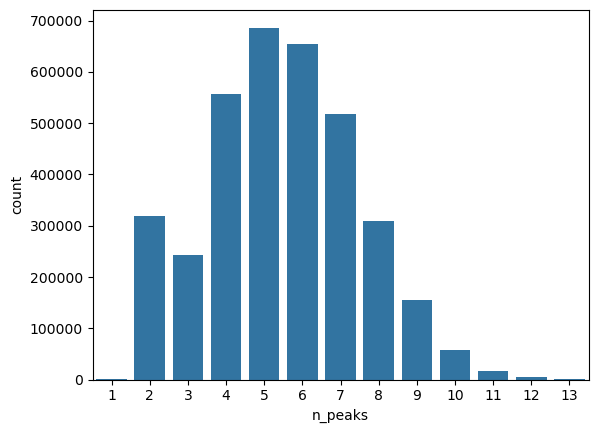

In [178]:
print(vep_ecdf['n_peaks'].describe())

import matplotlib.pyplot as plt
import seaborn as sns
sns.barplot(data=vep_ecdf['n_peaks'].value_counts())
plt.show()


#### Run UMAP on VEP KDE 

In [180]:
# Create a matrix with both ECDF values and VEP statistics
vep_ecdf_pivot = vep_ecdf.pivot_table(
    index=['id','model_location', 'protein', 'scoring_strategy', 'mutant', 'clinsig', 'n_haplotypes', 'n_peaks',
           'x_min', 'x_max','x_range', 'x_std', 'x_var'],
    columns='grid_index',
    values='ecdf'
)

In [123]:
# Run UMAP
model, embedding, nan_indices = utils.run_umap(vep_ecdf_pivot, 
                                               filter=False)

Running UMAP
UMAP(n_jobs=1, random_state=42, verbose=True)
Sat May  3 01:12:27 2025 Construct fuzzy simplicial set
Sat May  3 01:12:27 2025 Finding Nearest Neighbors
Sat May  3 01:12:27 2025 Building RP forest with 14 trees


/home/schilder/.conda/envs/esm2/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/home/schilder/.conda/envs/esm2/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Sat May  3 01:12:27 2025 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	Stopping threshold met -- exiting after 3 iterations
Sat May  3 01:12:28 2025 Finished Nearest Neighbor Search
Sat May  3 01:12:28 2025 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Sat May  3 01:13:13 2025 Finished embedding


/home/schilder/.conda/envs/esm2/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



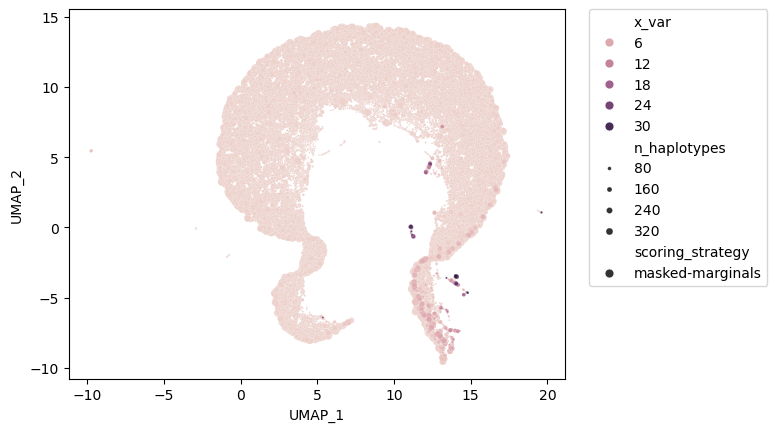

In [181]:
ecdf_umap_df = pd.DataFrame(embedding, 
                            index=vep_ecdf_pivot.index, 
                            columns=[f'UMAP_{i+1}' for i in range(embedding.shape[1])]
                            ).reset_index()

import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=ecdf_umap_df.sort_values('x_var', ascending=True),
                x='UMAP_1',
                y='UMAP_2',
                size='n_haplotypes',
                sizes=(1, 30),
                hue='x_var',
                style='scoring_strategy',
                )
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)


In [ ]:
import plotly.express as px

fig = px.scatter(ecdf_umap_df.sort_values('x_range', ascending=True),
                 x='UMAP_1',
                 y='UMAP_2',
                 color='x_range',
                 size='n_haplotypes',
                 size_max=5,
                 symbol='scoring_strategy',
                 hover_data=['model_location', 'protein', 'scoring_strategy'], 
                 hover_name='protein',
                 opacity=0.75)
# Reduce the height of the color bar
fig.update_layout(coloraxis_colorbar=dict(len=0.6))  # Reduce colorbar height to 60% of default
# Remove marker border
fig.update_traces(marker=dict(line=dict(width=0)))
fig.show()

#### Run hierarchical clustering on VEP KDE 

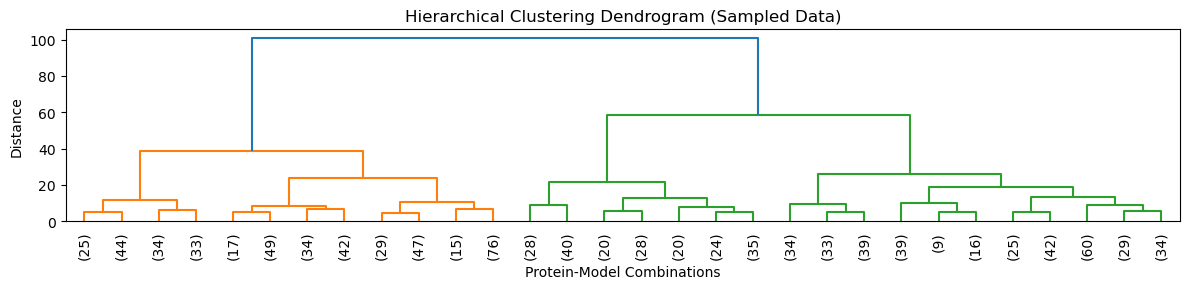

Number of clusters: 10
Cluster distribution: cluster
1     4730
2     5967
3     5600
4     1980
5     1643
6     2881
7     3952
8     1634
9     2490
10    4361
Name: count, dtype: int64


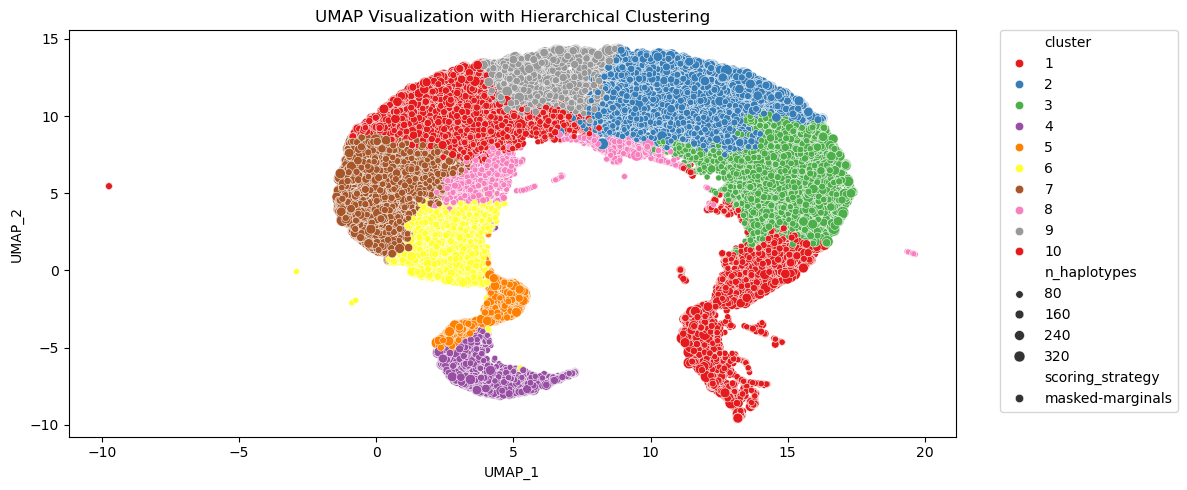

Cluster statistics:
grid_index   n_peaks                      n_haplotypes                
                mean median min max count         mean median min  max
cluster                                                               
1           3.208457    3.0   1  11  4730    67.203594   50.0   4  389
2           6.273169    6.0   2  12  5967    55.429864   43.0   4  389
3           5.246964    5.0   2  11  5600    55.883036   42.0   4  389
4           3.582828    3.0   2  10  1980    62.547980   48.0   4  389
5           4.357882    4.0   1   9  1643    75.813755   56.0   9  389
6           5.804582    6.0   2  12  2881    48.698022   34.0   3  389
7           6.014423    6.0   2  12  3952    63.907895   50.0   6  389
8           7.073439    7.0   2  13  1634    13.629131    7.0   3  389
9           6.220080    6.0   2  13  2490    65.713253   51.0   6  389
10          6.678973    7.0   2  13  4361    54.603073   41.0   5  389


In [182]:
# Perform hierarchical clustering on the VEP KDE data
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import numpy as np

# Sample data if it's too large (for faster clustering)
n_samples = min(1000, len(vep_ecdf_pivot))
if len(vep_ecdf_pivot) > n_samples:
    # Use stratified sampling to maintain distribution
    sampled_indices = np.random.choice(
        len(vep_ecdf_pivot), 
        size=n_samples, 
        replace=False
    )
    data_for_clustering = vep_ecdf_pivot.iloc[sampled_indices]
else:
    data_for_clustering = vep_ecdf_pivot

# Perform hierarchical clustering (faster with reduced dataset)
Z = linkage(data_for_clustering, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 3))
dendrogram(Z, 
           truncate_mode='lastp',  # show only the last p merged clusters
           p=30,  # show only the last 30 merged clusters
           leaf_rotation=90.,
           leaf_font_size=10.)
plt.title('Hierarchical Clustering Dendrogram (Sampled Data)')
plt.xlabel('Protein-Model Combinations')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

# Cut the dendrogram to get clusters
n_clusters = 10  # You can adjust this based on the dendrogram
clusters = fcluster(Z, n_clusters, criterion='maxclust')

# Map clusters back to original data if sampled
if len(vep_ecdf_pivot) > n_samples:
    # Train a simple classifier to predict clusters for all data points
    from sklearn.neighbors import KNeighborsClassifier
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(data_for_clustering, clusters)
    all_clusters = knn.predict(vep_ecdf_pivot)
    vep_ecdf_pivot['cluster'] = all_clusters
else:
    vep_ecdf_pivot['cluster'] = clusters

print(f"Number of clusters: {n_clusters}")
print(f"Cluster distribution: {pd.Series(vep_ecdf_pivot['cluster']).value_counts().sort_index()}")

# Visualize clusters in UMAP space
groupby_cols = ['model_location', 'protein', 'scoring_strategy','mutant','n_haplotypes','n_peaks']
ecdf_umap_df['cluster'] = ecdf_umap_df.set_index(groupby_cols).index.map(
    vep_ecdf_pivot.reset_index().set_index(groupby_cols)['cluster']
)

plt.figure(figsize=(12, 5))
sns.scatterplot(data=ecdf_umap_df,
                x='UMAP_1',
                y='UMAP_2',
                hue='cluster',
                size='n_haplotypes',
                style='scoring_strategy',
                palette='Set1'
                )
plt.title('UMAP Visualization with Hierarchical Clustering')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

# Analyze cluster characteristics
cluster_stats = vep_ecdf_pivot.reset_index().groupby('cluster').agg({
    'n_peaks': ['mean', 'median', 'min', 'max', 'count'],
    'n_haplotypes': ['mean', 'median', 'min', 'max']
})
print("Cluster statistics:")
print(cluster_stats)


In [183]:
vep_ecdf_pivot

,,,,,,,,,,,,grid_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,cluster
id,model_location,protein,scoring_strategy,mutant,clinsig,n_haplotypes,n_peaks,x_min,x_max,x_range,x_std,x_var,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
esm2_t33_650M_UR50D_NP_000007.1_masked-marginals_A113D_16_6,esm2_t33_650M_UR50D,NP_000007.1,masked-marginals,A113D,path,16,6,-5.800485,-5.689598,0.110887,0.028002,0.000784,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.125000,0.125000,0.250000,0.312500,0.375000,0.375000,0.437500,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.562500,0.562500,0.562500,0.562500,0.625000,0.625000,0.625000,0.625000,0.625000,0.687500,0.687500,0.687500,0.687500,0.750000,0.750000,0.750000,0.750000,0.750000,0.750000,0.750000,0.750000,0.750000,0.750000,0.875000,0.875000,0.875000,0.875000,0.875000,0.875000,0.875000,0.875000,0.875000,0.875000,0.875000,0.875000,0.875000,0.875000,0.875000,0.875000,0.875000,0.875000,0.875000,0.875000,0.875000,0.875000,0.875000,0.875000,0.875000,0.875000,0.875000,0.875000,0.875000,0.875000,0.875000,0.937500,0.937500,1.0,10
esm2_t33_650M_UR50D_NP_000007.1_masked-marginals_A113T_16_9,esm2_t33_650M_UR50D,NP_000007.1,masked-marginals,A113T,likely_path,16,9,-2.950999,-2.836770,0.114230,0.025054,0.000628,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.187500,0.187500,0.187500,0.187500,0.187500,0.187500,0.250000,0.312500,0.312500,0.312500,0.437500,0.437500,0.437500,0.500000,0.500000,0.562500,0.562500,0.562500,0.562500,0.687500,0.687500,0.687500,0.687500,0.750000,0.750000,0.750000,0.750000,0.750000,0.750000,0.750000,0.750000,0.750000,0.750000,0.812500,0.812500,0.812500,0.812500,0.812500,0.812500,0.812500,0.875000,0.875000,0.937500,0.937500,0.937500,0.937500,0.937500,0.937500,0.937500,0.937500,0.937500,0.937500,0.937500,1.0,7
esm2_t33_650M_UR50D_NP_000007.1_masked-marginals_A136V_16_7,esm2_t33_650M_UR50D,NP_000007.1,masked-marginals,A136V,path,16,7,-4.132521,-4.052058,0.080462,0.017550,0.000308,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.062500,0.125000,0.125000,0.125000,0.125000,0.187500,0.187500,0.187500,0.187500,0.187500,0.187500,0.250000,0.312500,0.312500,0.312500,0.312500,0.375000,0.437500,0.437500,0.437500,0.500000,0.500000,0.562500,0.562500,0.562500,0.562500,0.562500,0.562500,0.562500,0.625000,0.750000,0.750000,0.750000,0.750000,0.812500,0.812500,0.812500,0.812500,0.812500,0.812500,0.812500,0.875000,0.875000,0.875000,0.875000,0.875000,0.875000,0.875000,0.875000,0.875000,0.875000,0.937500,0.937500,0.937500,0.937500,0.937500,0.937500,0.937500,0.937500,0.937500,0.937500,0.937500,0.937500,0.937500,0.937500,0.937500,0.937500,0.937500,0.937500,0.937500,0.937500,0.937500,0.937500,0.937500,0.937500,1.0,10
esm2_t33_650M_UR50D_NP_000007.1_masked-marginals_A165T_16_5,esm2_t33_650M_UR50D,NP_000007.1,masked-marginals,A165T,likely_path,16,5,-3.178061,-3.073959,0.104103,0.023342,0.000545,0.062500,0.062500,0.062500,0.062500,0.125000,0.125000,0.187500,0.187500,

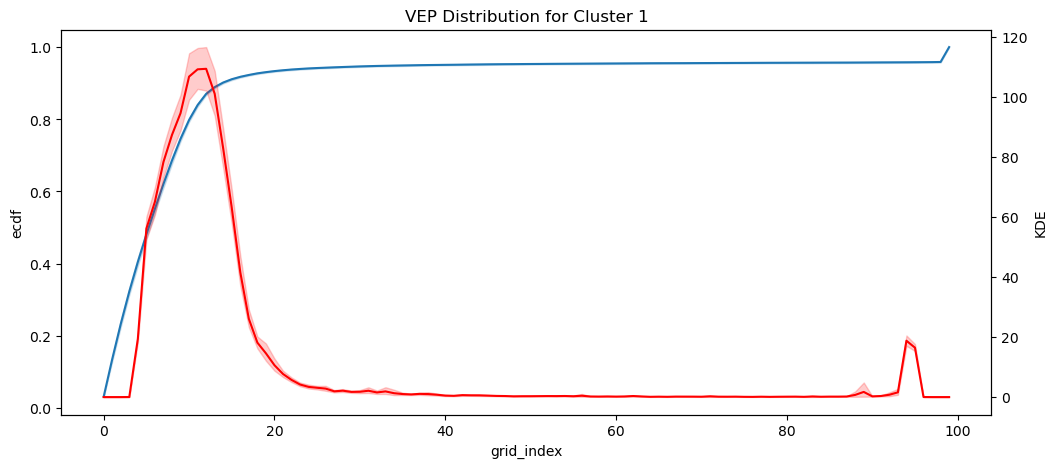

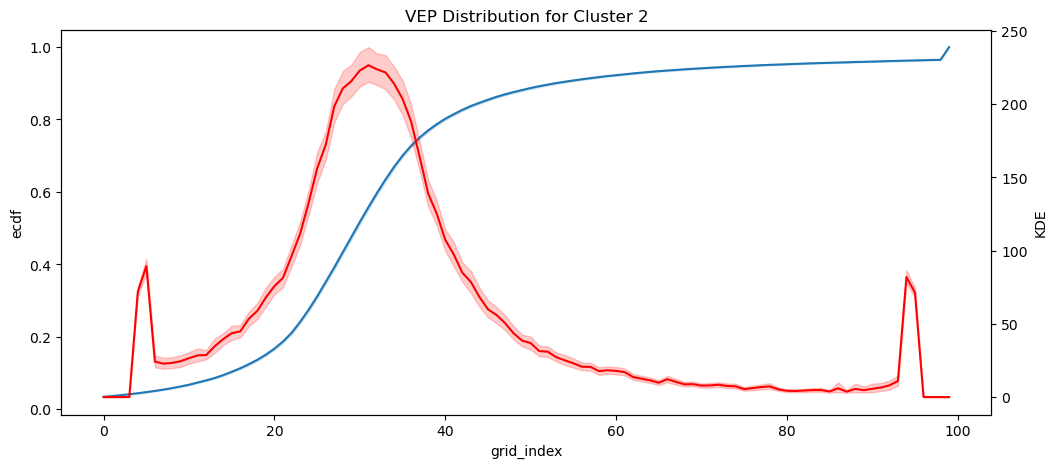

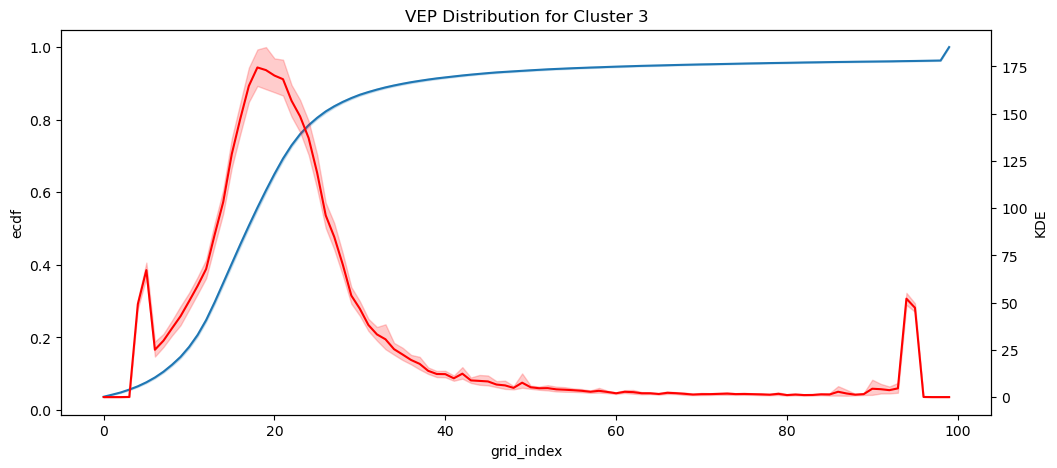

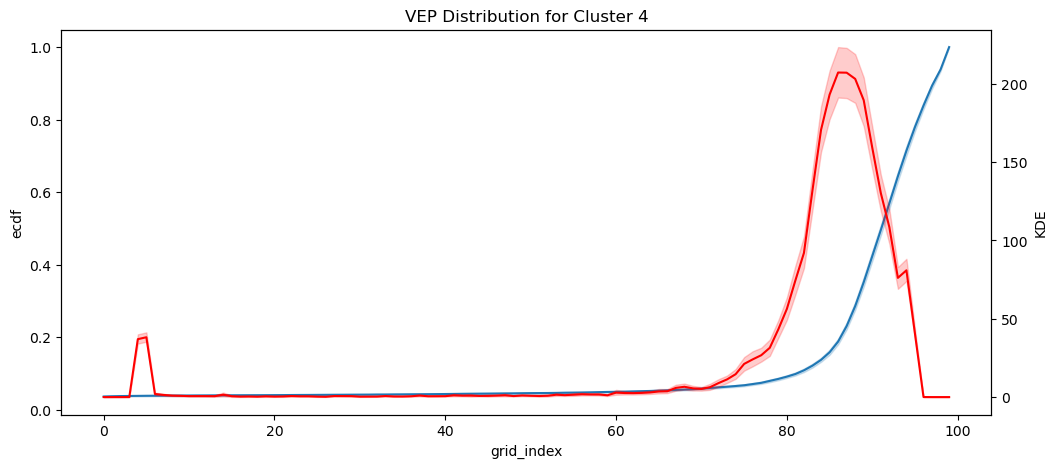

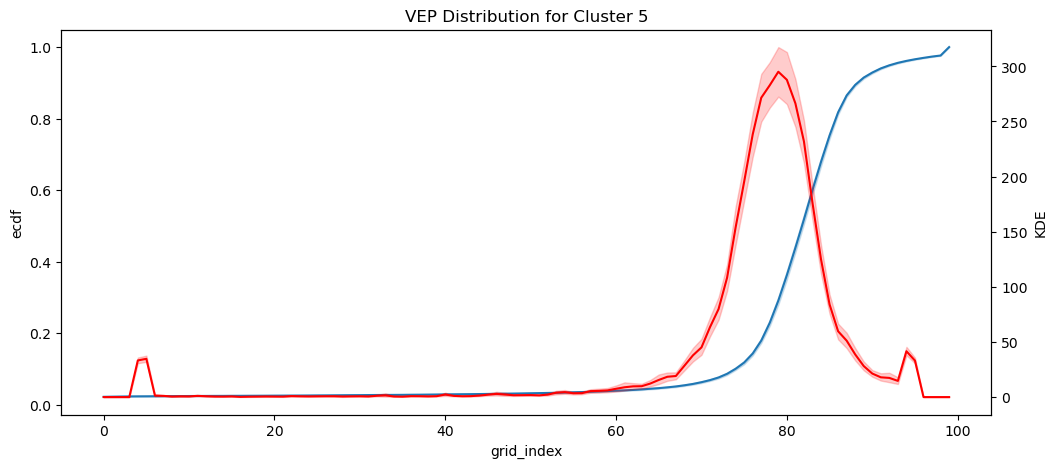

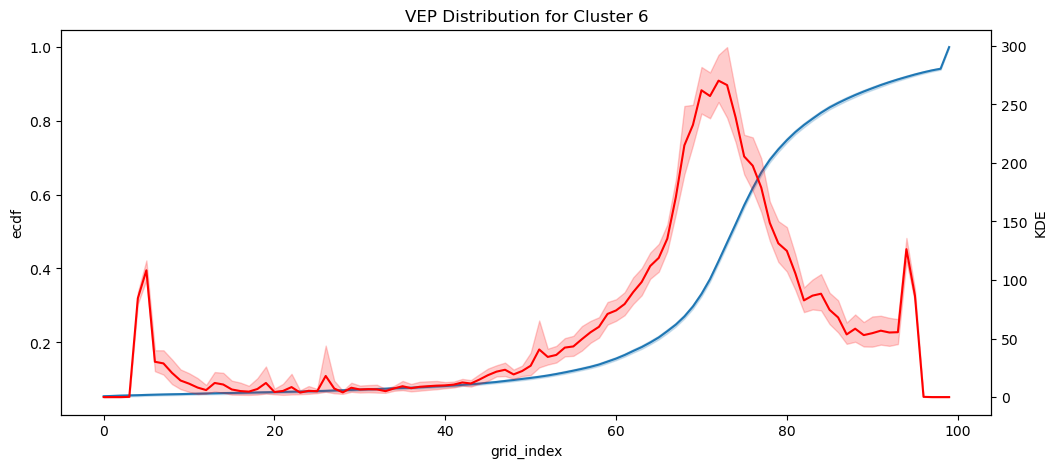

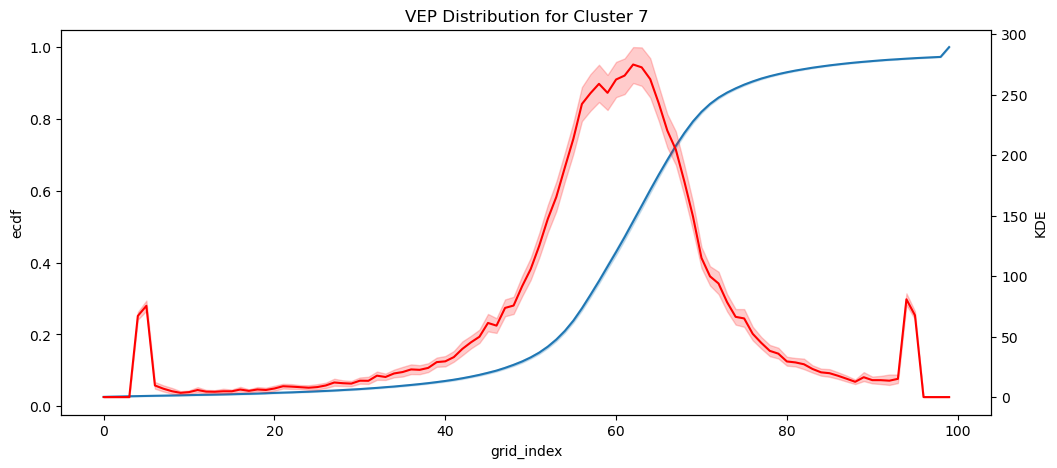

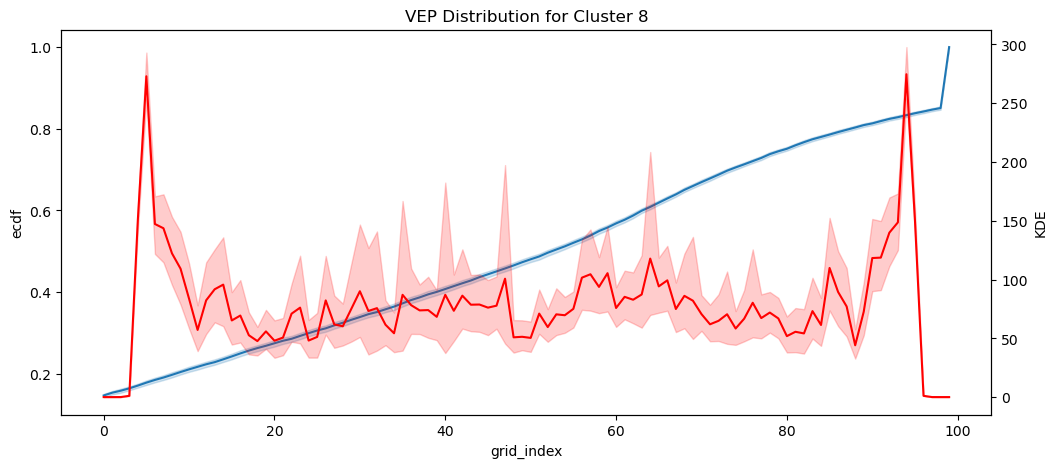

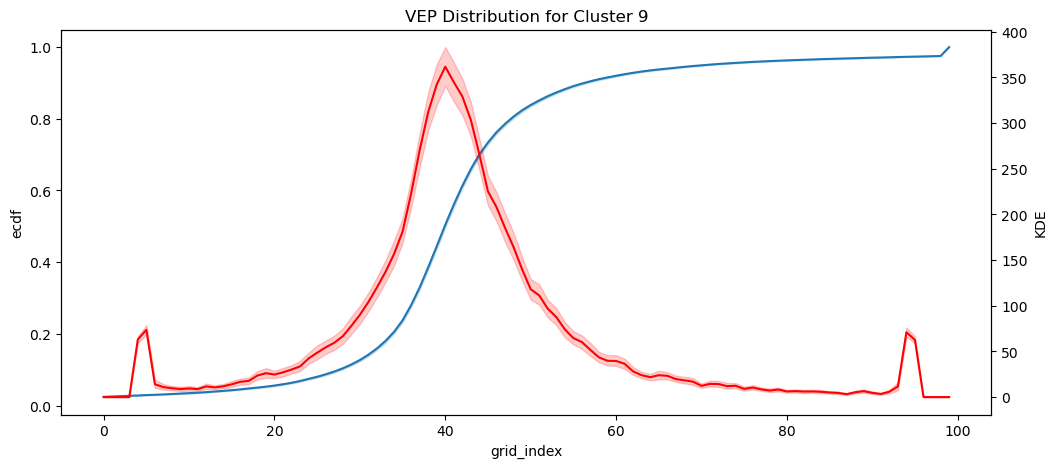

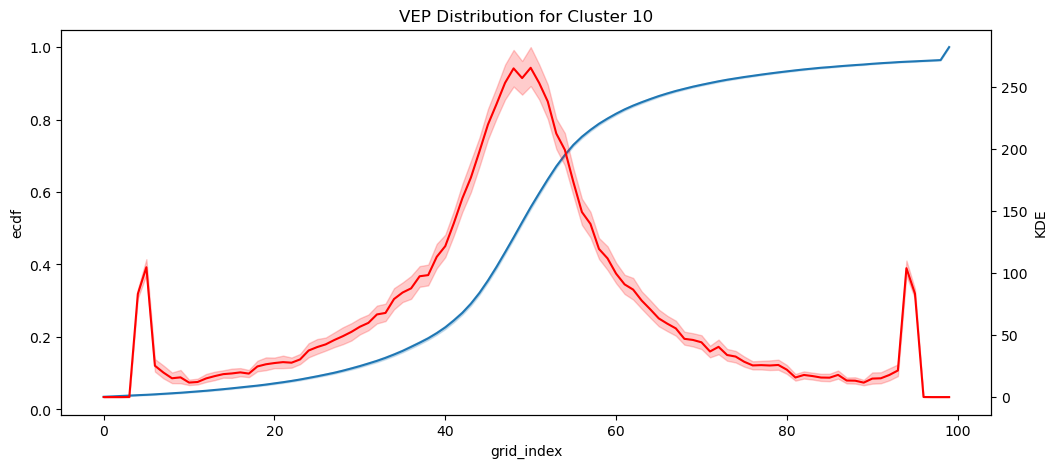

In [198]:
# Plot the VEP distribution for each cluster
for cluster in vep_ecdf_pivot['cluster'].sort_values().unique():
    plt.figure(figsize=(12, 5))
    # Filter the data correctly by using the cluster column in ecdf_umap_df
    ids = vep_ecdf_pivot.loc[vep_ecdf_pivot['cluster'] == cluster].reset_index()['id'].unique()
    cluster_data = vep_ecdf.loc[vep_ecdf['id'].isin(ids)]
    sns.lineplot(data=cluster_data,
                x='grid_index',
                y='ecdf')
    # Create a second y-axis for kde
    ax2 = plt.twinx()
    sns.lineplot(data=cluster_data,
                x='grid_index',
                y='kde',
                ax=ax2,
                color='red')
    ax2.set_ylabel('KDE')
    plt.title(f'VEP Distribution for Cluster {cluster}')
    plt.show()

In [2]:
ecdf_umap_df_path = 'results/vep_ecdf_umap.tsv.gz'
if os.path.exists(ecdf_umap_df_path) and 'ecdf_umap_df' not in locals():
    print("Loading cached ECDF UMAP data")
    ecdf_umap_df = pd.read_csv(ecdf_umap_df_path, sep='\t')
else:
    ecdf_umap_df.to_csv(ecdf_umap_df_path, sep='\t')


Loading cached ECDF UMAP data


#### Gprofiler enrichment of each VEP modality


In [96]:
# Create a dictionary where keys are n_peaks and values are unique proteins
peak_protein_dict = {n_peak: list(set(proteins)) for n_peak, proteins in 
                     ecdf_umap_df.groupby(['n_peaks'])['protein'].apply(list).items()}

# Create a dictionary where keys are n_peaks and values are unique proteins
cluster_protein_dict = {cluster: list(set(proteins)) for cluster, proteins in 
                     ecdf_umap_df.groupby(['cluster'])['protein'].apply(list).items()}

ecdf_umap_df['x_var_quantile'] = pd.qcut(ecdf_umap_df['x_var'], q=10, labels=False)
variance_protein_dict = {x_var: list(set(proteins)) for x_var, proteins in 
                         ecdf_umap_df.groupby(['x_var_quantile'])['protein'].apply(list).items()}


In [98]:
from gprofiler import GProfiler

gp = GProfiler(return_dataframe=True)
gp_df = gp.profile(organism='hsapiens',
                   background=ecdf_umap_df['protein'].unique().tolist(),
                   query=variance_protein_dict
                   )
print(gp_df.shape)

(348, 14)


    source      native                                               name  \
0       HP  HP:0000006                     Autosomal dominant inheritance   
1       HP  HP:0000734                                      Disinhibition   
2       HP  HP:0000752                                      Hyperactivity   
3       HP  HP:5200263                      Abnormally increased volition   
4    GO:BP  GO:0050789                   regulation of biological process   
..     ...         ...                                                ...   
323     HP  HP:0000007                    Autosomal recessive inheritance   
338     HP  HP:0003110                   Abnormality of urine homeostasis   
339     HP  HP:0011458                                  Abdominal symptom   
342     HP  HP:0001939              Abnormality of metabolism/homeostasis   
343     HP  HP:0012379  Abnormal circulating enzyme concentration or a...   

          p_value  significant  \
0    1.181404e-20         True   
1    1.

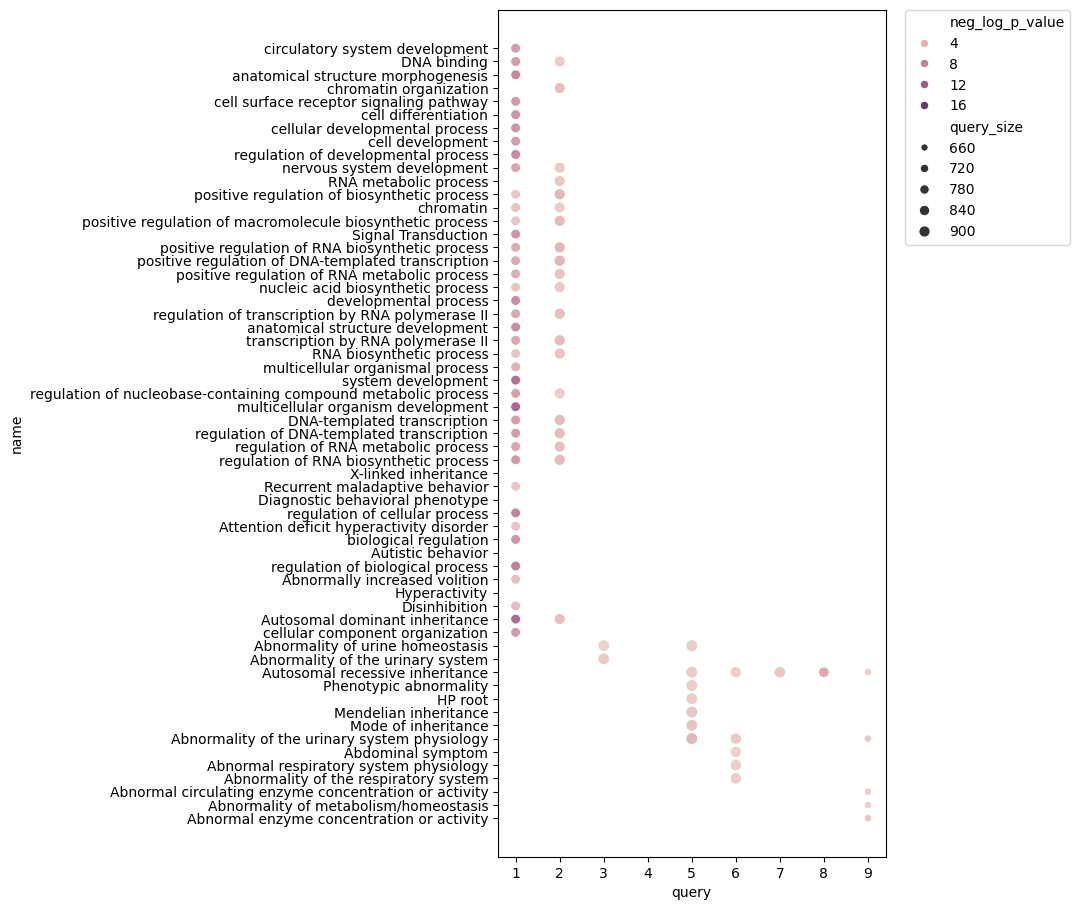

In [105]:

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
gp_df['query'] = gp_df['query'].astype(int).astype(str)
top_n = 20
if top_n is not None:
    gp_top = gp_df.groupby('query').head(top_n)
else:
    gp_top = gp_df

gp_df['neg_log_p_value'] = -np.log10(gp_df['p_value'])
print(gp_top)

plt.figure(figsize=(5, 11))
# Convert query groups to categorical with ordered categories to ensure proper ordering
ordered_queries = [str(i) for i in range(1, max(gp_df['query'].astype(int).unique())+1)]  # Clusters 1-10 in order
plot_data = gp_df[gp_df['name'].isin(gp_top['name'])].sort_values(['query','neg_log_p_value'])
plot_data['query'] = pd.Categorical(plot_data['query'], categories=ordered_queries, ordered=True)

sns.scatterplot(data=plot_data,
            x='query',
            y='name',
            hue='neg_log_p_value',
            size='query_size',
            )

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.show()



### Benign/Pathogenic Ratio

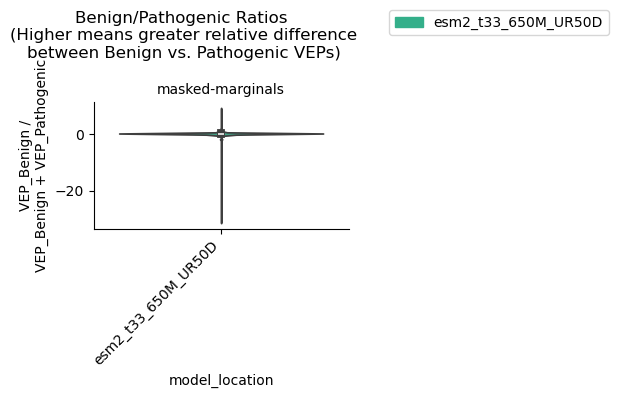

In [103]:
vep_pbratios = va.plot_vep_bpratios(vep_df,
                                     y=['benign_path_ratio','benign_path_ratio_strict'][1]
                                     )

## Plots: Single Protein

### Violin plots: wt-marginals

In [98]:
va.plot_vep_violin(vep_df, 
                #    model_location="esm2_t33_650M_UR50D",
                   max_proteins=1,
                   max_models=1,
                   save_path="results/plots/vep_violin;esm2_t33_650M_UR50D;wt-marginals.png",
                   scoring_strategy="wt-marginals")

Filtered 0.5% of rows with NAs in col 'VEP'


ValueError: Number of rows must be a positive integer, not 0

<Figure size 600x0 with 0 Axes>

### Violin plots: masked-marginals

Filtered 0.7% of rows with NAs in col 'VEP'


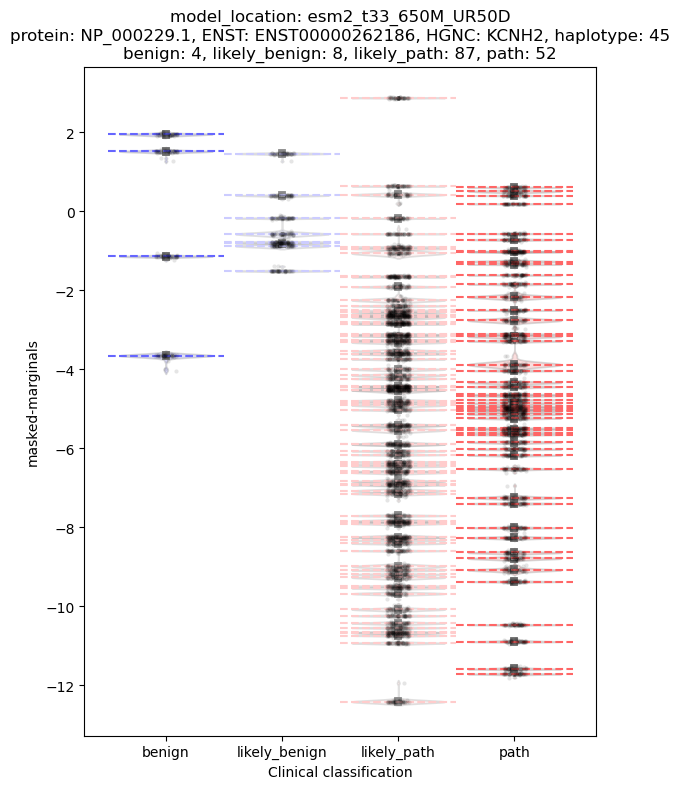

In [196]:
va.plot_vep_violin(vep_df, 
                   model_location="esm2_t33_650M_UR50D",
                    max_proteins=1,
                    max_models=1,
                    save_path="results/plots/vep_violin;esm2_t33_650M_UR50D;masked-marginals.png",
                    scoring_strategy="masked-marginals")

### Haplotype Representiveness

In [88]:
vep_df['VEP_percentile'] = vep_df.groupby(['model_location', 'protein', 'mutant','scoring_strategy'])['VEP'].rank(pct=True)
vep_df[['VEP_percentile']]

,VEP_percentile
0,0.397059
1,0.519608
2,0.447619
3,0.495238
4,0.504762
...,...
3861747,0.400000
3861748,0.288889
3861749,0.733333
3861750,0.288889


### Reference Representativeness: Percentiles

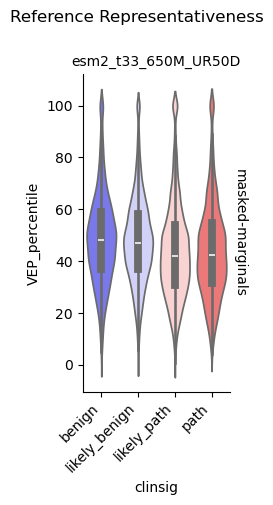

In [12]:
va.plot_vep_percentiles(vep_df, 
                        col='model_location',
                        row='scoring_strategy',
                        height=5,
                        aspect=.5,
                        save_path="results/plots/vep_percentiles.png")

In [93]:
vep_df.loc[vep_df['is_ref']==True]['VEP_percentile'].describe()

count    68385.000000
mean         0.483787
std          0.174238
min          0.007042
25%          0.369048
50%          0.473684
75%          0.581818
max          1.000000
Name: VEP_percentile, dtype: float64

In [ ]:
# Get genes where the reference is the LEAST representitive

In [34]:
vep_df.loc[:,'VEP_percentile_deivation'] = abs(vep_df['VEP_percentile'] - 50)
most_deviant_ref = vep_df.loc[vep_df['is_ref']==True].groupby(['model_location', 'scoring_strategy','protein']).agg({'VEP_percentile_deivation':['count','min','max','mean','median']}).sort_values(('VEP_percentile_deivation','mean'), ascending=False).reset_index()
most_deviant_ref.head(10)

model_location  scoring_strategy      protein  \
                                                        
0  esm2_t33_650M_UR50D  masked-marginals  NP_000052.1   
1  esm2_t33_650M_UR50D  masked-marginals  NP_000107.1   
2  esm2_t33_650M_UR50D  masked-marginals  NP_005667.2   
3  esm2_t33_650M_UR50D  masked-marginals  NP_006297.2   
4  esm2_t33_650M_UR50D  masked-marginals  NP_006512.2   
5  esm2_t33_650M_UR50D  masked-marginals  NP_005620.1   
6  esm2_t33_650M_UR50D  masked-marginals  NP_004484.1   
7  esm2_t33_650M_UR50D  masked-marginals  NP_821133.1   
8  esm2_t33_650M_UR50D  masked-marginals  NP_004178.2   
9  esm2_t33_650M_UR50D  masked-marginals  NP_036412.1   

  VEP_percentile_deivation                           
                     count   min   max  mean median  
0                       76  50.0  50.0  50.0   50.0  
1                       20  50.0  50.0  50.0   50.0  
2                       10  50.0  50.0  50.0   50.0  
3                       79  50.0  50.0  50.0   50.0  
4                       14  50.0  50.0  50.0   50.0  
5                       57  50.0  50.0  50.0   50.0  
6                       14  50.0  50.0  50.0   50.0  
7                       24  50.0  50.0  50.0   50.0  
8                       65  50.0  50.0  50.0   50.0  
9                       10  50.0  50.0  50.0   50.0

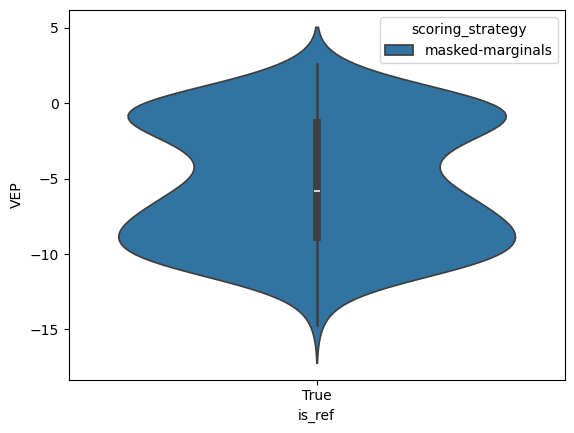

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a FacetGrid to facet by scoring_strategy
g = sns.violinplot(data=vep_df.loc[vep_df['protein'].isin(most_deviant_ref['protein'].unique()[:12])],
                   x='is_ref',
                   y='VEP',
                   hue='scoring_strategy',
                   )
plt.show()

In [46]:
from gprofiler import GProfiler
gp = GProfiler(return_dataframe=True)
gp_df = gp.profile(organism='hsapiens',
           background=vep_files['protein'].unique().tolist(),
           query=most_deviant_ref['protein'].unique().tolist()[:50]
           )
gp_df


,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents
0,HP,HP:0001417,X-linked inheritance,0.000516,True,A mode of inheritance that is observed for tra...,148,50,17,2142,0.34,0.114865,query_1,[HP:0034345]
1,HP,HP:0001419,X-linked recessive inheritance,0.003431,True,A mode of inheritance that is observed for rec...,109,50,14,2142,0.28,0.128440,query_1,[HP:0001417]


## Precision-Recall 

### Add edit distance metrics

In [94]:
# Add the number of edits (variants relative to the reference) per haplotype
vep_df = utils.add_edits(vep_df)

# Scale edits by protein sequence length
seq_lens = {seq:len(seq) for seq in vep_df['protein_sequence']}
vep_df['protein_sequence_len'] = vep_df['protein_sequence'].map(seq_lens)
vep_df['edits_scaled'] = vep_df['edits'] / vep_df['protein_sequence_len']
vep_df['edits_clipped'] = vep_df['edits'].clip(upper=20)
vep_df.loc[:,'edits_scaled_rounded'] = vep_df['edits_scaled'].round(3)

# vep_df['edits_scaled_quartiles'] = pd.qcut(vep_df.groupby(['protein','mutant'])['edits_scaled'], q=10, labels=False)
# vep_df['edits_scaled_quartiles'].value_counts()

Filter to only include variants with high-confidence annotations.

In [95]:
print(vep_df.groupby("clinsig")['CLNREVSTAT'].value_counts())

vep_qc = vep_df.loc[(vep_df['clinsig'].isin(["path","benign"])) &\
                    (vep_df['CLNREVSTAT'].isin(['reviewed_by_expert_panel','practice_guideline']))]

clinsig        CLNREVSTAT                                          
benign         criteria_provided,_single_submitter                     333452
               criteria_provided,_multiple_submitters,_no_conflicts    259188
               reviewed_by_expert_panel                                 67894
likely_benign  criteria_provided,_single_submitter                     927813
               criteria_provided,_multiple_submitters,_no_conflicts    513666
               reviewed_by_expert_panel                                 13291
likely_path    criteria_provided,_single_submitter                     723754
               criteria_provided,_multiple_submitters,_no_conflicts    437389
               reviewed_by_expert_panel                                 43397
path           criteria_provided,_single_submitter                     307734
               criteria_provided,_multiple_submitters,_no_conflicts    132227
               reviewed_by_expert_panel                                 97

In [96]:
vep_pr = va.compute_precision_recall(vep_qc,
                                     groupby_cols = ['model_location', 'scoring_strategy',
                                                     'protein',
                                                     'is_ref', 
                                                     'protein_sequence_len', 'haplotype',
                                                    #  'edits',
                                                    'edits_scaled_rounded'
                                                     ],
                                     agg_cols = ['protein','protein_sequence_len', 'haplotype'],
                                     x='VEP',
                                     y='DMS_bin_score')


Binarizing pathogenic vs benign labels


Computing precision and recall:   0%|          | 0/3639 [00:00<?, ?it/s]

In [99]:
print(vep_pr.shape)
vep_pr.head()

(43, 9)


,scoring_strategy,model_location,is_ref,edits_scaled_rounded,accuracy,auc,coef,intercept,n_samples
0,masked-marginals,esm1_t34_670M_UR50D,False,0.001,0.869699,0.862301,-0.418116,-2.301909,17097
1,masked-marginals,esm1_t34_670M_UR50D,False,0.002,0.951569,0.952633,-0.675808,-3.290716,4298
2,masked-marginals,esm1_t34_670M_UR50D,False,0.003,0.925488,0.828541,-0.700510,-3.176116,7567
3,masked-marginals,esm1_t34_670M_UR50D,False,0.004,1.000000,1.000000,-0.335300,-1.973312,104
4,masked-marginals,esm1_t34_670M_UR50D,False,0.005,0.966387,1.000000,-0.986889,-5.020192,328


In [101]:
vep_pr_ref_only = va.compute_precision_recall(vep_qc.loc[vep_qc['is_ref']==True],
                                     groupby_cols = ['model_location', 'scoring_strategy','protein'],
                                     agg_cols = ['protein'],
                                     x='VEP',
                                     y='DMS_bin_score')
vep_pr_ref_only['group'] = 'Ref only'
vep_pr_all = va.compute_precision_recall(vep_qc,
                                     groupby_cols = ['model_location', 'scoring_strategy','protein'],
                                     agg_cols = ['protein'],
                                     x='VEP',
                                     y='DMS_bin_score')
vep_pr_all['group'] = 'All'
vep_pr_grouped = pd.concat([vep_pr_ref_only, vep_pr_all])
vep_pr_grouped


Binarizing pathogenic vs benign labels


Computing precision and recall:   0%|          | 0/67 [00:00<?, ?it/s]

Binarizing pathogenic vs benign labels


Computing precision and recall:   0%|          | 0/69 [00:00<?, ?it/s]

,model_location,scoring_strategy,accuracy,auc,coef,intercept,n_samples,group
0,esm1_t34_670M_UR50D,masked-marginals,0.922827,0.923887,-0.626985,-2.935390,492,Ref only
1,esm1_t6_43M_UR50S,masked-marginals,0.867102,0.750367,-0.562018,-1.214258,196,Ref only
2,esm1b_t33_650M_UR50S,masked-marginals,0.941176,0.951724,-1.035698,-6.061322,34,Ref only
3,esm1v_t33_650M_UR90S_1,masked-marginals,0.970588,0.944828,-0.889119,-3.404146,34,Ref only
4,esm2_t12_35M_UR50D,masked-marginals,0.810120,0.787691,-0.339665,-0.364349,586,Ref only
5,esm2_t33_650M_UR50D,masked-marginals,0.937364,0.933678,-0.729286,-3.091472,196,Ref only
0,esm1_t34_670M_UR50D,masked-marginals,0.932224,0.923185,-0.998520,-6.114943,30296,All
1,esm1_t6_43M_UR50S,masked-marginals,0.867074,0.750241,-0.598848,-1.305849,19366,All
2,esm1b_t33_650M_UR50S,masked-marginals,0.940107,0.949987,-1.409723,-8.620766,1870,All
3,esm1v_t33_650M_UR90S_1,masked-marginals,0.970588,0.945562,-1.064717,-4.330592,1870,All


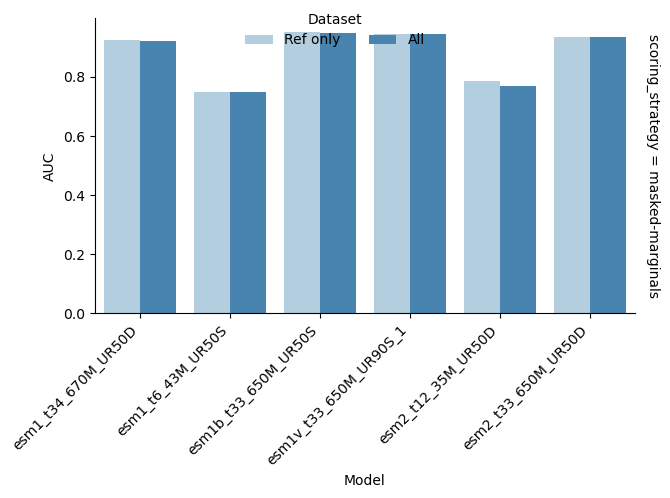

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a FacetGrid to facet by scoring_strategy
g = sns.FacetGrid(data=vep_pr_grouped,
                  row="scoring_strategy",
                  margin_titles=True,
                  height=5, 
                  aspect=1)

# Map the barplot to each facet
g.map_dataframe(sns.barplot, 
                x="model_location", 
                y="auc", 
                hue="group",
                palette='Blues')

# Fix x-axis labels - apply rotation to each subplot
for ax in g.axes.flat:
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Adjust layout and add titles
g.set_axis_labels("Model", "AUC")
# _rm_subplot_prefixes(g)

# Add a legend for the hue variable
g.add_legend(title="Dataset", loc='upper center', ncol=2)

plt.tight_layout()
plt.show()

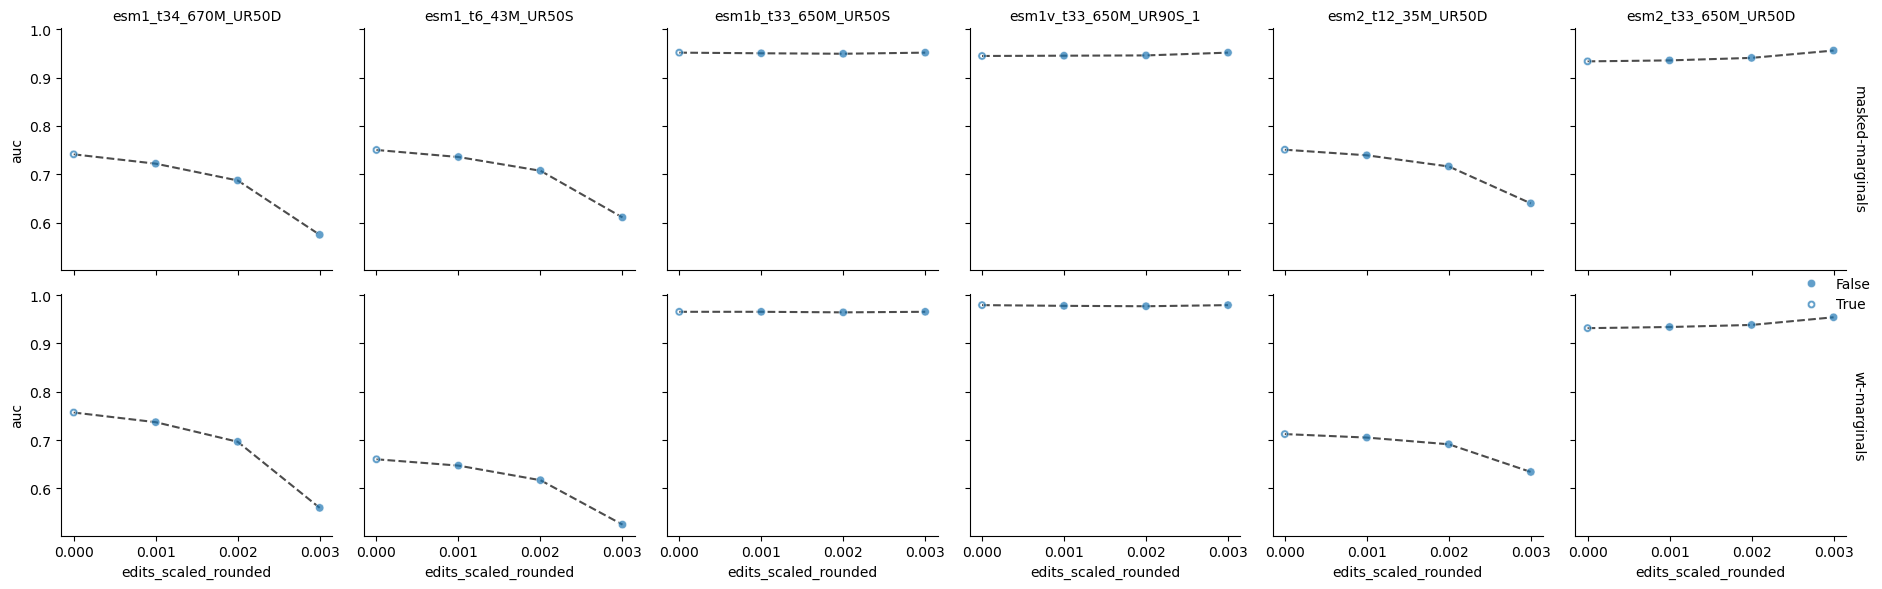

In [26]:
va.plot_auc_by_edits(vep_pr, #vep_pr.loc[vep_pr['edits'] < 20],
                      col="model_location",
                      row="scoring_strategy", 
                      style="is_ref",
                     x="edits_scaled_rounded", 
                     save_path="results/plots/vep_pr_auc_by_edits.png")

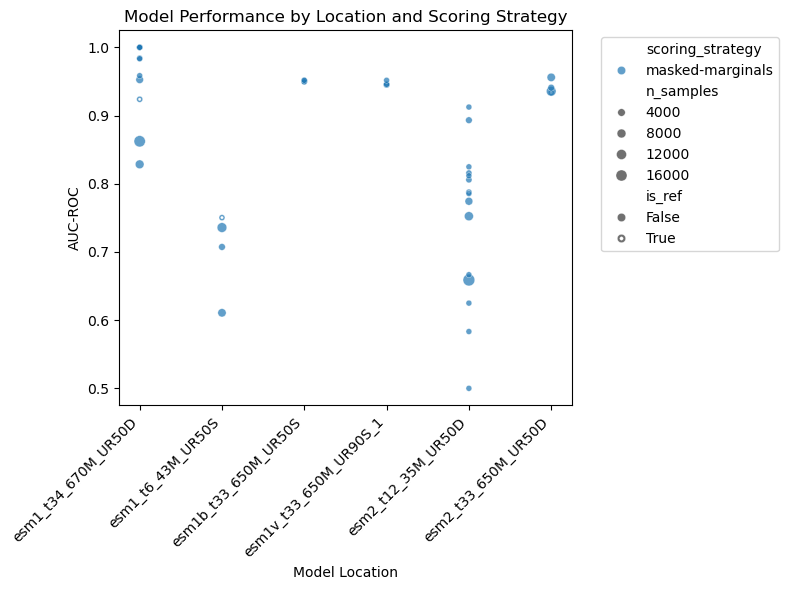

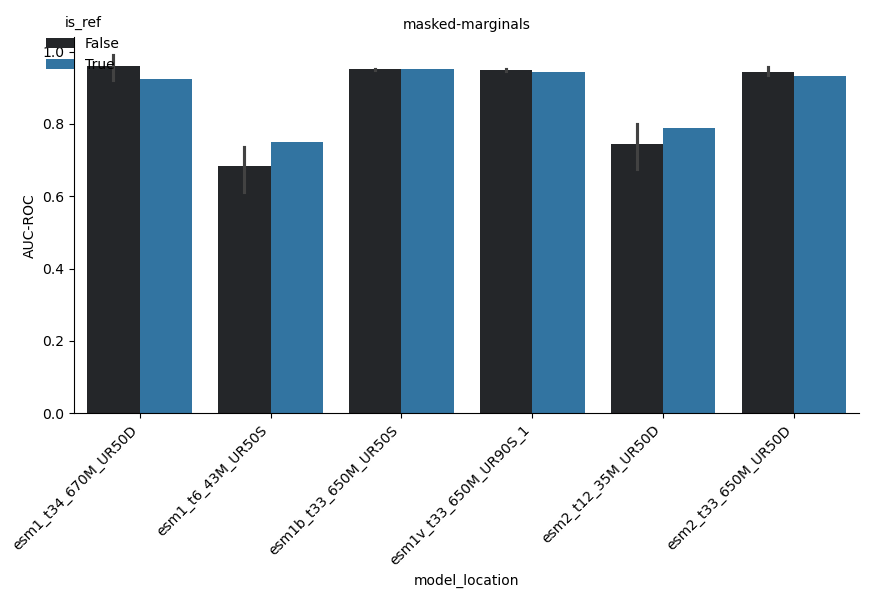

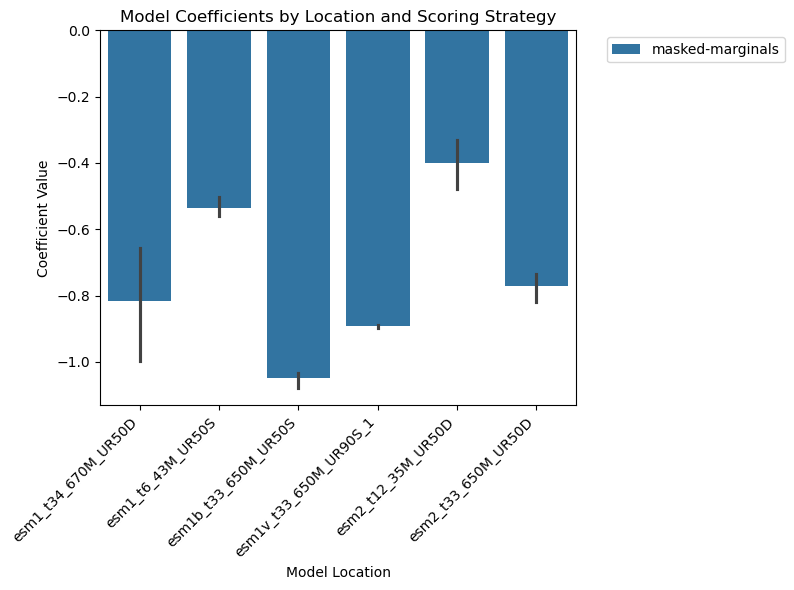

In [103]:
va.plot_precision_recall(vep_pr,
                         style='is_ref',
                         
                         save_path="results/plots/precision_recall.png",
                         hue='scoring_strategy')

### Pairwise correlations between haplotypes
Compute pairwise correlations between all haplotypes for a given protein.

In [105]:
# Group by protein and pivot to get haplotype columns
tqdm.pandas(desc="Pivoting VEP")
vep_pivot = vep_df.groupby('protein').progress_apply(lambda x: pd.pivot_table(x,
                                                                    index=['protein', 'mutant'],
                                                                    columns='edits_clipped',
                                                                    values='VEP',
                                                                    # Only include haplotypes for this protein
                                                                    dropna=True))
vep_pivot


Pivoting VEP:   0%|          | 0/1772 [00:00<?, ?it/s]

edits_clipped                          0          1          2         20  3   \
protein     protein     mutant                                                  
NP_000007.1 NP_000007.1 A113D   -7.708576  -7.715696  -7.693262 -7.758820 NaN   
                        A113T   -4.232880  -4.237339  -4.239253 -4.131114 NaN   
                        A136V   -2.095088  -2.079986  -2.093937 -2.206535 NaN   
                        A165T   -2.368854  -2.382868  -2.369235 -2.368831 NaN   
                        A205P   -5.687437  -5.676813  -5.668174 -5.591449 NaN   
...                                   ...        ...        ...       ...  ..   
NP_998885.1 NP_998885.1 R15L    -9.027851  -8.889543  -9.132408       NaN NaN   
                        S59L   -19.177984 -19.245420 -18.696195       NaN NaN   
                        S77G    -1.477943  -1.495848  -1.485637       NaN NaN   
                        T90P     3.208157   3.182882   2.964261       NaN NaN   
                        Y135H    2.782606   2.666708   2.839180       NaN NaN   

edits_clipped                   4   5   6   7   8   10  11  19  18  14  17  \
protein     protein     mutant                                               
NP_000007.1 NP_000007.1 A113D  NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
                        A113T  NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
                        A136V  NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
                        A165T  NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
                        A205P  NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
...                             ..  ..  ..  ..  ..  ..  ..  ..  ..  ..  ..   
NP_998885.1 NP_998885.1 R15L   NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
                        S59L   NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
                        S77G   NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
                        T90P   NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
                        Y135H  NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   

edits_clipped                   12  9   16  13  15  
protein     protein     mutant                      
NP_000007.1 NP_000007.1 A113D  NaN NaN NaN NaN NaN  
                        A113T  NaN NaN NaN NaN NaN  
                        A136V  NaN NaN NaN NaN NaN  
                        A165T  NaN NaN NaN NaN NaN  
                        A205P  NaN NaN NaN NaN NaN  
...                             ..  ..  ..  ..  ..  
NP_998885.1 NP_998885.1 R15L   NaN NaN NaN NaN NaN  
                        S59L   NaN NaN NaN NaN NaN  
                        S77G   NaN NaN NaN NaN NaN  
                        T90P   NaN NaN NaN NaN NaN  
                        Y135H  NaN NaN NaN NaN NaN  

[45278 rows x 21 columns]

In [106]:
vep_pivot.index.get_level_values('mutant').value_counts()

# Calculate percentage of non-NA values for each row
pct_nonna = (vep_pivot.notna().sum(axis=0) / vep_pivot.shape[0] * 100).round(2)

pct_nonna.describe()


count     21.000000
mean      17.549524
std       32.147812
min        0.020000
25%        0.080000
50%        0.530000
75%       17.370000
max      100.000000
dtype: float64

In [107]:
vep_pivot.index.get_level_values(0).nunique()

1772

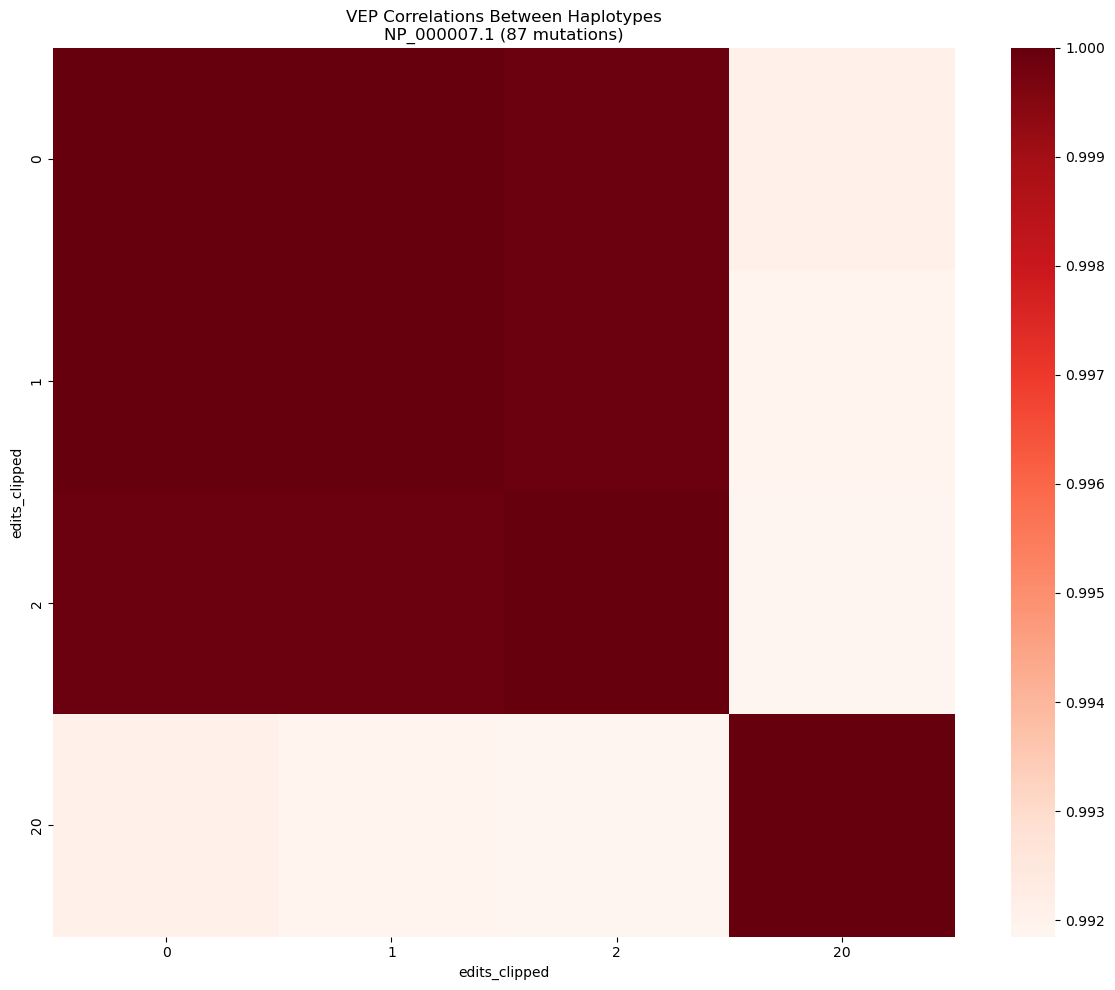

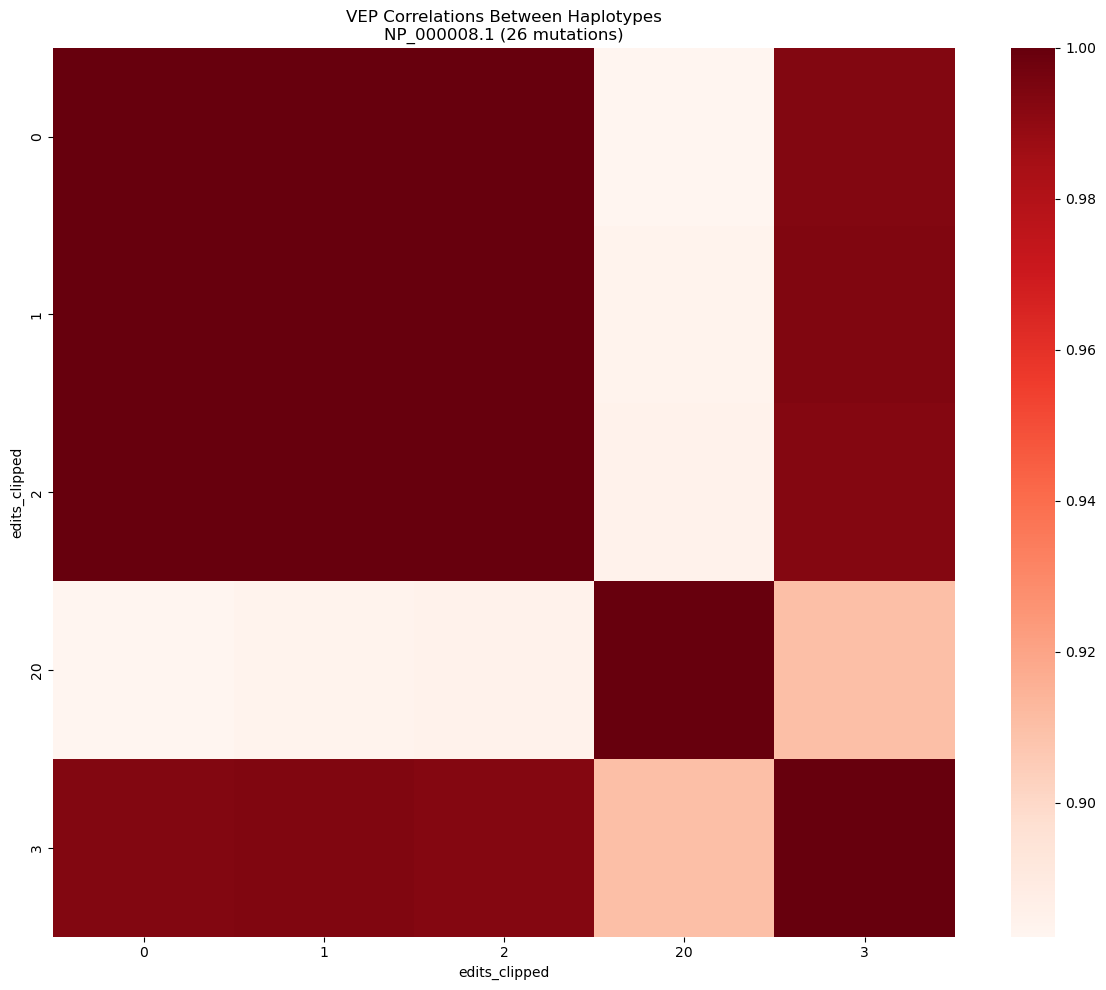

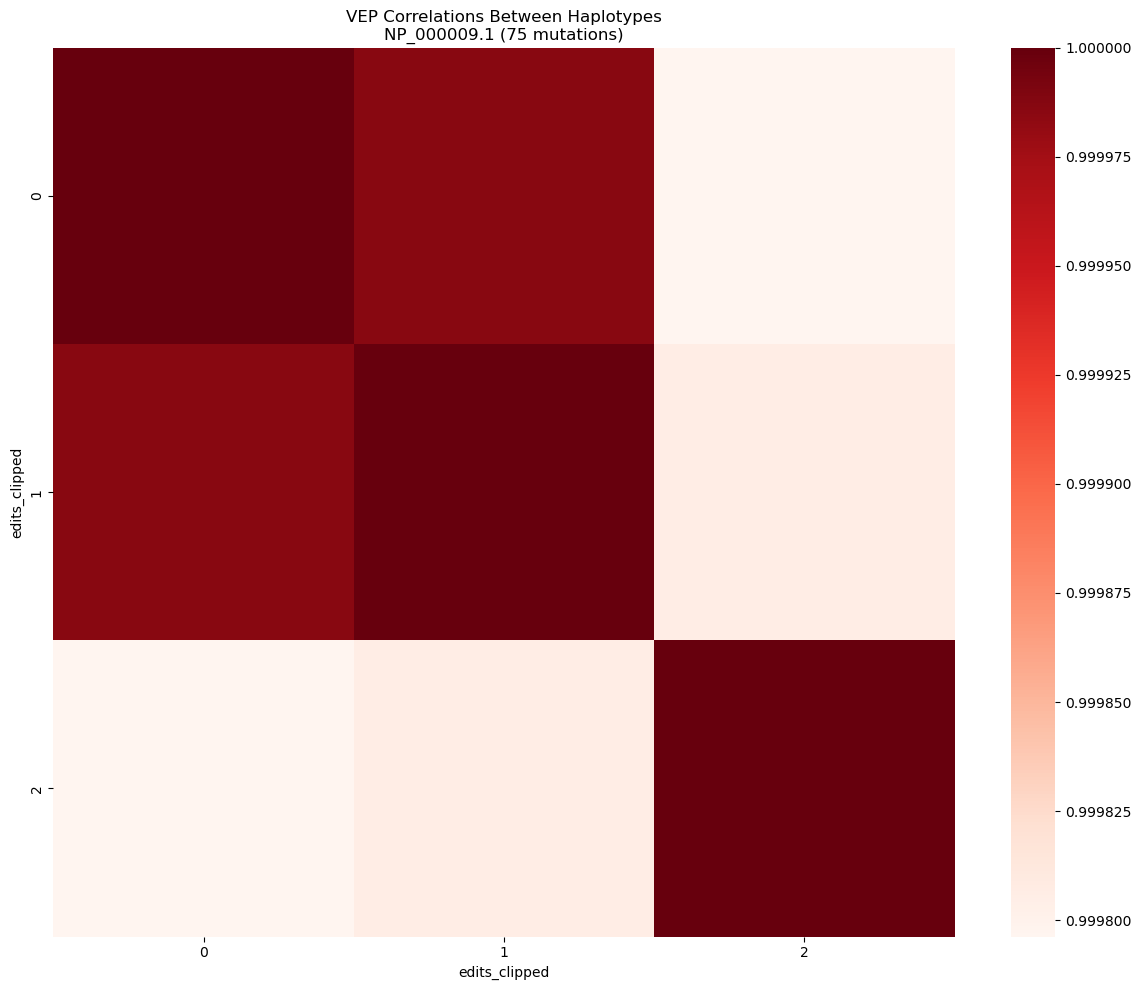

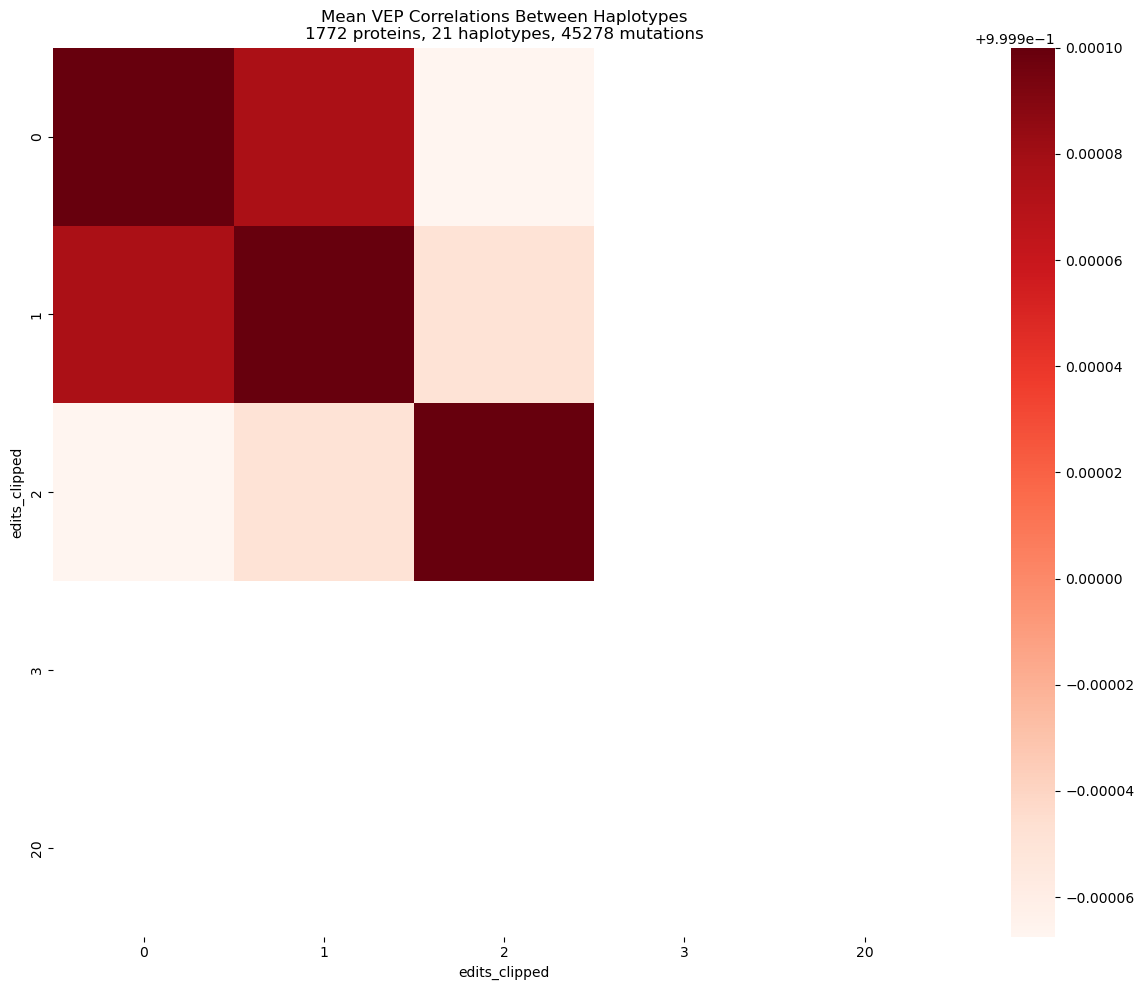

In [109]:
# Compute correlations within each protein
vep_corr = vep_pivot.groupby('protein').apply(lambda x: x.corr())
import matplotlib.pyplot as plt
import seaborn as sns
# Create list to store correlation matrices
corr_matrices = []

max_proteins = 3
# Get correlation matrix for each protein
for protein in vep_corr.index.get_level_values(0).unique()[:max_proteins]:
    corr_matrix = vep_corr.loc[protein]
    # Remove columns that are all NA
    corr_matrix = corr_matrix.dropna(axis=1, how='all')
    # Remove rows that are all NA 
    corr_matrix = corr_matrix.dropna(axis=0, how='all')
    plt.figure(figsize=(12,10))
    sns.heatmap(corr_matrix,
                cmap='Reds', 
                # center=vep_corr.mean().mean(),
                # vmin=vep_corr.min().min(),
                # vmax=vep_corr.max().max()
                )
    n_mutations = len(vep_pivot.loc[protein].index)
    plt.title(f'VEP Correlations Between Haplotypes\n{protein} ({n_mutations} mutations)')
    plt.tight_layout()
    plt.show()
    corr_matrices.append(corr_matrix)

# Calculate mean correlation matrix
mean_corr = sum(corr_matrices) / len(corr_matrices)

# Plot mean correlation heatmap
plt.figure(figsize=(12,10))
sns.heatmap(mean_corr,
            cmap='Reds',
            )
plt.title(f'Mean VEP Correlations Between Haplotypes\n{vep_pivot.index.get_level_values(0).nunique()} proteins, {len(vep_pivot.columns)} haplotypes, {len(vep_pivot.index)} mutations')
plt.tight_layout()
plt.show()
